In [ ]:
# ── Cell 1: Setup ──────────────────────────────────────────────
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(torch.cuda.get_device_name(0))  # Should say Tesla T4

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Tesla T4


In [ ]:
# ── Cell 2 (FIXED): Preprocessing ─────────────────────────────
DATA_PATH = '/content/drive/MyDrive/TheCook/data/'

SENSORS_TO_DROP = [1, 5, 6, 10, 16, 18, 19]
ALL_COLS = (['engine_id', 'cycle'] +
            [f'op{i}' for i in range(1, 4)] +
            [f's{i}' for i in range(1, 22)])
SENSOR_COLS = [f's{i}' for i in range(1, 22) if i not in SENSORS_TO_DROP]
OP_COLS     = ['op1', 'op2', 'op3']
RUL_CAP     = 125
WINDOW      = 30

def load_and_preprocess(subset='FD001'):
    train_df = pd.read_csv(f'{DATA_PATH}train_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    test_df  = pd.read_csv(f'{DATA_PATH}test_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    rul_df   = pd.read_csv(f'{DATA_PATH}RUL_{subset}.txt',
                           header=None, names=['RUL'])

    # Train RUL labels
    train_df['RUL'] = train_df.groupby('engine_id')['cycle'].transform(
        lambda x: x.max() - x)
    train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

    # Normalize sensors (fit on train only)
    scaler = MinMaxScaler()
    train_df[SENSOR_COLS] = scaler.fit_transform(train_df[SENSOR_COLS])
    test_df[SENSOR_COLS]  = scaler.transform(test_df[SENSOR_COLS])

    # Normalize op settings
    op_scaler = MinMaxScaler()
    train_df[OP_COLS] = op_scaler.fit_transform(train_df[OP_COLS])
    test_df[OP_COLS]  = op_scaler.transform(test_df[OP_COLS])

    # ── Train windows: all sliding windows ──
    def make_train_windows(df):
        X, Y, OPS = [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors = grp[SENSOR_COLS].values
            ops     = grp[OP_COLS].values
            ruls    = grp['RUL'].values
            for i in range(len(grp) - WINDOW + 1):
                X.append(sensors[i:i+WINDOW])
                OPS.append(ops[i:i+WINDOW])
                Y.append(ruls[i + WINDOW - 1])
        return (np.array(X, dtype=np.float32),
                np.array(OPS, dtype=np.float32),
                np.array(Y, dtype=np.float32))

    # ── Test windows: LAST window only per engine ──
    def make_test_windows(df, rul_df):
        X, Y, OPS = [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors   = grp[SENSOR_COLS].values
            ops       = grp[OP_COLS].values
            true_rul  = float(rul_df.loc[eid - 1, 'RUL'])
            true_rul  = min(true_rul, RUL_CAP)

            # Pad if engine has fewer cycles than window size
            if len(grp) < WINDOW:
                pad = WINDOW - len(grp)
                sensors = np.vstack([np.zeros((pad, sensors.shape[1])), sensors])
                ops     = np.vstack([np.zeros((pad, ops.shape[1])), ops])

            X.append(sensors[-WINDOW:])    # last 30 cycles
            OPS.append(ops[-WINDOW:])
            Y.append(true_rul)
        return (np.array(X, dtype=np.float32),
                np.array(OPS, dtype=np.float32),
                np.array(Y, dtype=np.float32))

    X_tr, OPS_tr, Y_tr = make_train_windows(train_df)
    X_te, OPS_te, Y_te = make_test_windows(test_df, rul_df)

    print(f"{subset} → Train: {X_tr.shape}, Test: {X_te.shape}")
    return X_tr, OPS_tr, Y_tr, X_te, OPS_te, Y_te, scaler, op_scaler

X_tr1, OPS_tr1, Y_tr1, X_te1, OPS_te1, Y_te1, scaler1, op_scaler1 = load_and_preprocess('FD001')
X_tr2, OPS_tr2, Y_tr2, X_te2, OPS_te2, Y_te2, scaler2, op_scaler2 = load_and_preprocess('FD002')

FD001 → Train: (17731, 30, 14), Test: (100, 30, 14)
FD002 → Train: (46219, 30, 14), Test: (259, 30, 14)


In [ ]:
# ── Cell 3 (FIXED): Dataset + Metrics ─────────────────────────
class CMAPSSDataset(Dataset):
    def __init__(self, X, OPS, Y):
        self.X   = torch.tensor(X)
        self.OPS = torch.tensor(OPS)
        self.Y   = torch.tensor(Y).unsqueeze(1)   # raw RUL, shape (N,1)

    def __len__(self): return len(self.Y)
    def __getitem__(self, i): return self.X[i], self.OPS[i], self.Y[i]

def phm_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0,
                     np.exp(-d / 13) - 1,
                     np.exp( d / 10) - 1)
    return float(np.sum(score))

def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, OPS, Y in loader:
            X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
            out = model(X, OPS)
            rul = out[0] if isinstance(out, tuple) else out
            # Model outputs in [0,1] → scale back to cycles
            preds.append((rul.cpu().numpy() * RUL_CAP))
            trues.append(Y.cpu().numpy())          # already raw RUL (not normalized)
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    rmse  = float(np.sqrt(np.mean((preds - trues)**2)))
    score = phm_score(trues, preds)
    return rmse, score

In [ ]:
# ── Cell 4: DCNN (Li et al. 2018) — bug-fixed ─────────────────
class DCNN(nn.Module):
    def __init__(self, n_feat=14):
        super().__init__()
        self.convs = nn.Sequential(
            nn.Conv1d(n_feat, 10, kernel_size=10, padding='same'), nn.Tanh(),
            nn.Conv1d(10,     10, kernel_size=10, padding='same'), nn.Tanh(),
            nn.Conv1d(10,     10, kernel_size=10, padding='same'), nn.Tanh(),
            nn.Conv1d(10,     10, kernel_size=10, padding='same'), nn.Tanh(),
            nn.Conv1d(10,      1, kernel_size=3,  padding='same'), nn.Tanh(),
        )
        self.fc = nn.Linear(WINDOW, 1)

    def forward(self, X, OPS=None):   # OPS ignored — DCNN doesn't use regime
        # X: (B, 30, 14) → permute → (B, 14, 30) for Conv1d
        out = self.convs(X.permute(0, 2, 1))   # (B, 1, 30)
        out = self.fc(out.squeeze(1))           # (B, 1)
        return torch.sigmoid(out)              # predict in [0,1], will scale by RUL_CAP

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X, OPS, Y in loader:
        X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
        Y_norm = Y / RUL_CAP          # normalize target to [0,1]
        optimizer.zero_grad()
        out = model(X, OPS)
        rul = out[0] if isinstance(out, tuple) else out
        loss = criterion(rul, Y_norm)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def run_experiment(model, X_tr, OPS_tr, Y_tr, X_te, OPS_te, Y_te,
                   epochs=50, batch=256, lr=1e-3, label=''):
    tr_ds = CMAPSSDataset(X_tr, OPS_tr, Y_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for ep in range(1, epochs+1):
        loss = train_one_epoch(model, tr_loader, optimizer, criterion)
        if ep % 10 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {loss:.4f} | RMSE {rmse:.2f} | Score {score:.0f}")

    rmse, score = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE: {rmse:.2f} | Score: {score:.0f}")
    return rmse, score

In [ ]:
# ── Cell 5: Train DCNN on FD001 ───────────────────────────────
dcnn_fd001 = DCNN().to(device)
rmse_d1, score_d1 = run_experiment(
    dcnn_fd001, X_tr1, OPS_tr1, Y_tr1, X_te1, OPS_te1, Y_te1,
    epochs=50, batch=512, lr=1e-3, label='DCNN-FD001'
)

[DCNN-FD001] Ep  10 | Loss 0.0139 | RMSE 13.71 | Score 287
[DCNN-FD001] Ep  20 | Loss 0.0122 | RMSE 13.42 | Score 288
[DCNN-FD001] Ep  30 | Loss 0.0121 | RMSE 13.70 | Score 307
[DCNN-FD001] Ep  40 | Loss 0.0112 | RMSE 13.10 | Score 297
[DCNN-FD001] Ep  50 | Loss 0.0114 | RMSE 14.04 | Score 396

✅ [DCNN-FD001] FINAL → RMSE: 14.04 | Score: 396


In [ ]:
# ── Cell 6: Proposed Regime-Aware Model ────────────────────────
class RegimeAwareTransformer(nn.Module):
    """
    Sensor Encoder  : Transformer encoder over 30-cycle sensor window
    Regime Encoder  : Linear projection of op settings per timestep
    Cross-Attention : Sensor features attend to regime context
    Dual Heads      : (1) RUL scalar  (2) K-step future sensor trajectory
    """
    def __init__(self, n_feat=14, n_op=3, d_model=64,
                 n_heads=4, n_layers=2, K=10):
        super().__init__()
        self.K = K          # trajectory horizon (future steps to predict)
        self.d_model = d_model

        # ── Sensor Encoder ──
        self.sensor_proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1,
            batch_first=True)
        self.sensor_enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── Regime Encoder ──
        self.regime_proj = nn.Linear(n_op, d_model)

        # ── Cross-Attention (sensor attends to regime) ──
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=0.1, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)

        # ── RUL Head ──
        self.rul_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()       # output in [0,1], scaled by RUL_CAP
        )

        # ── Trajectory Head (K future sensor vectors) ──
        self.traj_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, K * n_feat),
            nn.Sigmoid()       # sensor values in [0,1] after MinMax
        )
        self.n_feat = n_feat

    def forward(self, X, OPS):
        # X   : (B, 30, 14)  sensor window
        # OPS : (B, 30,  3)  op settings window

        # Sensor encoding
        s = self.sensor_proj(X)                        # (B, 30, d_model)
        s = self.sensor_enc(s)                         # (B, 30, d_model)

        # Regime encoding
        r = self.regime_proj(OPS)                      # (B, 30, d_model)

        # Cross-attention: sensor context attends to regime
        fused, _ = self.cross_attn(query=s, key=r, value=r)
        fused = self.cross_norm(fused + s)             # residual (B, 30, d_model)

        # Pool over time → single vector
        ctx = fused.mean(dim=1)                        # (B, d_model)

        # Dual heads
        rul  = self.rul_head(ctx)                      # (B, 1)
        traj = self.traj_head(ctx)                     # (B, K*14)
        traj = traj.view(-1, self.K, self.n_feat)      # (B, K, 14)

        return rul, traj

In [ ]:
# ── Cell 7: Training loop with composite loss ──────────────────
def train_proposed(model, X_tr, OPS_tr, Y_tr,
                   X_te, OPS_te, Y_te,
                   epochs=60, batch=256, lr=1e-3,
                   lambda_traj=0.3, label='Proposed-FD001'):

    tr_ds = CMAPSSDataset(X_tr, OPS_tr, Y_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs)
    mse = nn.MSELoss()

    for ep in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for X, OPS, Y in tr_loader:
            X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
            Y_norm = Y / RUL_CAP              # (B, 1) in [0,1]

            optimizer.zero_grad()
            rul, traj = model(X, OPS)

            # RUL loss
            loss_rul = mse(rul, Y_norm)

            # Trajectory self-supervised loss:
            # predict the NEXT K timesteps of sensors from the window itself
            # target = last K rows of the input sensor window (B, K, 14)
            K = model.K
            traj_target = X[:, -K:, :]       # (B, K, 14) — already normalized
            loss_traj = mse(traj, traj_target)

            loss = loss_rul + lambda_traj * loss_traj
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if ep % 10 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {total_loss/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse, score = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE: {rmse:.2f} | Score: {score:.0f}")
    return rmse, score

In [ ]:
# ── Cell 8: Sanity check — single batch overfit test ──────────
# Run this BEFORE full training. Should overfit to near-zero loss in ~30 steps.
model_check = RegimeAwareTransformer().to(device)
X_s = torch.tensor(X_tr1[:32]).to(device)
O_s = torch.tensor(OPS_tr1[:32]).to(device)
Y_s = torch.tensor(Y_tr1[:32]).unsqueeze(1).to(device) / RUL_CAP

opt_check = torch.optim.Adam(model_check.parameters(), lr=1e-3)
mse_check  = nn.MSELoss()

for step in range(50):
    opt_check.zero_grad()
    rul, traj = model_check(X_s, O_s)
    loss = mse_check(rul, Y_s)
    loss.backward()
    opt_check.step()
    if (step+1) % 10 == 0:
        print(f"Step {step+1:3d} | Loss {loss.item():.6f}")

print("\n✅ Overfit test done. Loss should be < 0.001 by step 50.")

Step  10 | Loss 0.058086
Step  20 | Loss 0.013971
Step  30 | Loss 0.003706
Step  40 | Loss 0.001359
Step  50 | Loss 0.000678

✅ Overfit test done. Loss should be < 0.001 by step 50.


In [ ]:
# ── Cell 9: Train Proposed Model on FD001 ─────────────────────
proposed_fd001 = RegimeAwareTransformer(K=10).to(device)
rmse_p1, score_p1 = train_proposed(
    proposed_fd001,
    X_tr1, OPS_tr1, Y_tr1,
    X_te1, OPS_te1, Y_te1,
    epochs=60, batch=256, lr=1e-3,
    lambda_traj=0.3, label='Proposed-FD001'
)

[Proposed-FD001] Ep  10 | Loss 0.0160 | RMSE 16.27 | Score 649
[Proposed-FD001] Ep  20 | Loss 0.0139 | RMSE 14.66 | Score 483
[Proposed-FD001] Ep  30 | Loss 0.0116 | RMSE 14.57 | Score 431
[Proposed-FD001] Ep  40 | Loss 0.0105 | RMSE 15.57 | Score 466
[Proposed-FD001] Ep  50 | Loss 0.0096 | RMSE 16.51 | Score 533
[Proposed-FD001] Ep  60 | Loss 0.0093 | RMSE 16.55 | Score 560

✅ [Proposed-FD001] FINAL → RMSE: 16.55 | Score: 560


In [ ]:
# ── Cell 10: DCNN on FD002 ─────────────────────────────────────
dcnn_fd002 = DCNN().to(device)
rmse_d2, score_d2 = run_experiment(
    dcnn_fd002, X_tr2, OPS_tr2, Y_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=50, batch=512, lr=1e-3, label='DCNN-FD002'
)

[DCNN-FD002] Ep  10 | Loss 0.0420 | RMSE 28.81 | Score 7672
[DCNN-FD002] Ep  20 | Loss 0.0385 | RMSE 23.89 | Score 11501
[DCNN-FD002] Ep  30 | Loss 0.0381 | RMSE 22.44 | Score 7654
[DCNN-FD002] Ep  40 | Loss 0.0343 | RMSE 22.02 | Score 4234
[DCNN-FD002] Ep  50 | Loss 0.0339 | RMSE 21.29 | Score 4871

✅ [DCNN-FD002] FINAL → RMSE: 21.29 | Score: 4871


In [ ]:
# ── Cell 11: Proposed on FD002 ─────────────────────────────────
proposed_fd002 = RegimeAwareTransformer(K=10).to(device)
rmse_p2, score_p2 = train_proposed(
    proposed_fd002,
    X_tr2, OPS_tr2, Y_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=60, batch=256, lr=1e-3,
    lambda_traj=0.3, label='Proposed-FD002'
)

[Proposed-FD002] Ep  10 | Loss 0.0632 | RMSE 23.06 | Score 2923
[Proposed-FD002] Ep  20 | Loss 0.0588 | RMSE 19.57 | Score 3240
[Proposed-FD002] Ep  30 | Loss 0.0569 | RMSE 20.31 | Score 2095
[Proposed-FD002] Ep  40 | Loss 0.0554 | RMSE 18.06 | Score 2444
[Proposed-FD002] Ep  50 | Loss 0.0544 | RMSE 17.85 | Score 2126
[Proposed-FD002] Ep  60 | Loss 0.0541 | RMSE 17.72 | Score 2120

✅ [Proposed-FD002] FINAL → RMSE: 17.72 | Score: 2120


In [ ]:
# ── Cell 12: Standard Transformer (no regime conditioning) ─────
class StandardTransformer(nn.Module):
    def __init__(self, n_feat=14, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, X, OPS=None):   # OPS ignored
        out = self.enc(self.proj(X))  # (B, 30, d_model)
        ctx = out.mean(dim=1)
        return self.head(ctx)         # (B, 1)

# FD001
st_fd001 = StandardTransformer().to(device)
rmse_st1, score_st1 = run_experiment(
    st_fd001, X_tr1, OPS_tr1, Y_tr1,
    X_te1, OPS_te1, Y_te1,
    epochs=50, batch=256, lr=1e-3, label='StdTransformer-FD001')

# FD002
st_fd002 = StandardTransformer().to(device)
rmse_st2, score_st2 = run_experiment(
    st_fd002, X_tr2, OPS_tr2, Y_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=50, batch=256, lr=1e-3, label='StdTransformer-FD002')

[StdTransformer-FD001] Ep  10 | Loss 0.0120 | RMSE 15.40 | Score 502
[StdTransformer-FD001] Ep  20 | Loss 0.0067 | RMSE 18.51 | Score 1040
[StdTransformer-FD001] Ep  30 | Loss 0.0032 | RMSE 19.13 | Score 1264
[StdTransformer-FD001] Ep  40 | Loss 0.0020 | RMSE 18.81 | Score 1185
[StdTransformer-FD001] Ep  50 | Loss 0.0013 | RMSE 18.57 | Score 1135

✅ [StdTransformer-FD001] FINAL → RMSE: 18.57 | Score: 1135
[StdTransformer-FD002] Ep  10 | Loss 0.0316 | RMSE 21.36 | Score 9167
[StdTransformer-FD002] Ep  20 | Loss 0.0283 | RMSE 18.78 | Score 1889
[StdTransformer-FD002] Ep  30 | Loss 0.0257 | RMSE 17.84 | Score 2238
[StdTransformer-FD002] Ep  40 | Loss 0.0237 | RMSE 18.45 | Score 4183
[StdTransformer-FD002] Ep  50 | Loss 0.0217 | RMSE 18.73 | Score 2448

✅ [StdTransformer-FD002] FINAL → RMSE: 18.73 | Score: 2448


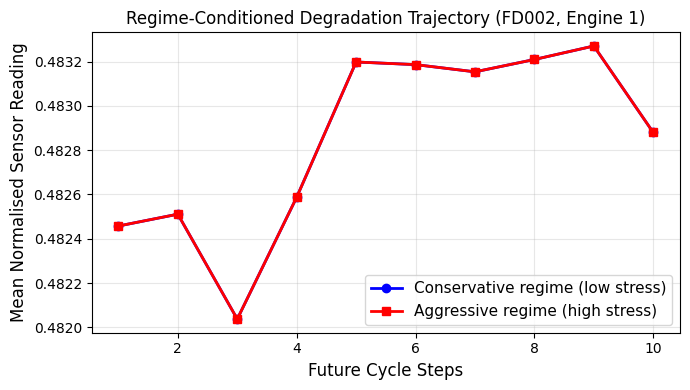

Figure saved.


In [ ]:
# ── Cell 13: Trajectory Divergence Figure ──────────────────────
# Pick one test engine from FD002, simulate under two regime extremes

def simulate_trajectory(model, window_X, window_OPS, future_ops, K=10):
    """
    model      : trained RegimeAwareTransformer
    window_X   : (30, 14) last observed sensor window
    window_OPS : (30, 3)  last observed op settings
    future_ops : (K, 3)   regime to simulate forward under
    Returns    : (K, 14) predicted future sensor trajectory
    """
    model.eval()
    X   = torch.tensor(window_X).unsqueeze(0).to(device)    # (1,30,14)
    OPS = torch.tensor(window_OPS).unsqueeze(0).to(device)  # (1,30,3)
    with torch.no_grad():
        _, traj = model(X, OPS)   # traj: (1, K, 14)
    return traj.squeeze(0).cpu().numpy()   # (K, 14)

# ── Pick engine 0 from FD002 test set ──
eng_idx  = 0
win_X    = X_te2[eng_idx]     # (30, 14)
win_OPS  = OPS_te2[eng_idx]   # (30, 3)

# ── Two regime extremes (min and max op settings observed in FD002) ──
op_min = np.zeros((10, 3), dtype=np.float32)   # conservative (low stress)
op_max = np.ones ((10, 3), dtype=np.float32)   # aggressive   (high stress)

traj_conservative = simulate_trajectory(proposed_fd002, win_X, win_OPS, op_min, K=10)
traj_aggressive   = simulate_trajectory(proposed_fd002, win_X, win_OPS, op_max, K=10)

# ── Plot: mean sensor degradation across all 14 sensors ──
steps = np.arange(1, 11)
mean_cons = traj_conservative.mean(axis=1)   # (K,)
mean_aggr = traj_aggressive.mean(axis=1)     # (K,)

plt.figure(figsize=(7, 4))
plt.plot(steps, mean_cons, 'b-o', linewidth=2, label='Conservative regime (low stress)')
plt.plot(steps, mean_aggr, 'r-s', linewidth=2, label='Aggressive regime (high stress)')
plt.fill_between(steps, mean_cons, mean_aggr, alpha=0.15, color='gray')
plt.xlabel('Future Cycle Steps', fontsize=12)
plt.ylabel('Mean Normalised Sensor Reading', fontsize=12)
plt.title('Regime-Conditioned Degradation Trajectory (FD002, Engine 1)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('trajectory_divergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

In [ ]:
# ── Cell 14: Ablation — Regime-Blind Variant ───────────────────
class RegimeBlindTransformer(RegimeAwareTransformer):
    """Same architecture but regime input is zeroed out — ablation."""
    def forward(self, X, OPS):
        OPS_zero = torch.zeros_like(OPS)   # blind to regime
        return super().forward(X, OPS_zero)

blind_fd002 = RegimeBlindTransformer(K=10).to(device)
rmse_bl2, score_bl2 = train_proposed(
    blind_fd002,
    X_tr2, OPS_tr2, Y_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=60, batch=256, lr=1e-3,
    lambda_traj=0.3, label='RegimeBlind-FD002')

[RegimeBlind-FD002] Ep  10 | Loss 0.0620 | RMSE 22.13 | Score 8986
[RegimeBlind-FD002] Ep  20 | Loss 0.0596 | RMSE 20.48 | Score 3425
[RegimeBlind-FD002] Ep  30 | Loss 0.0564 | RMSE 17.95 | Score 1766
[RegimeBlind-FD002] Ep  40 | Loss 0.0540 | RMSE 19.25 | Score 1939
[RegimeBlind-FD002] Ep  50 | Loss 0.0532 | RMSE 19.29 | Score 2397
[RegimeBlind-FD002] Ep  60 | Loss 0.0529 | RMSE 19.15 | Score 2612

✅ [RegimeBlind-FD002] FINAL → RMSE: 19.15 | Score: 2612


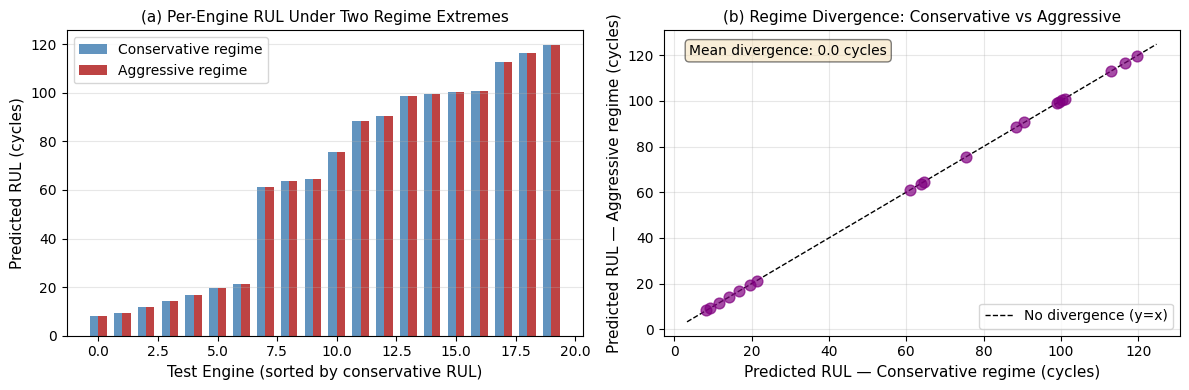


Mean RUL conservative: 64.7 | aggressive: 64.7
Mean divergence (cons - aggr): 0.0 cycles


In [ ]:
# ── Cell 15: Fixed Key Figure — RUL divergence across engines ──
proposed_fd002.eval()

# Pick 20 test engines from FD002
n_engines = 20
rul_conservative = []
rul_aggressive   = []

with torch.no_grad():
    for i in range(n_engines):
        X_e   = torch.tensor(X_te2[i]).unsqueeze(0).to(device)    # (1,30,14)

        # Conservative: all op settings = 0 (min stress)
        ops_cons = torch.zeros(1, 30, 3).to(device)
        rul_c, _ = proposed_fd002(X_e, ops_cons)
        rul_conservative.append(rul_c.item() * RUL_CAP)

        # Aggressive: all op settings = 1 (max stress)
        ops_aggr = torch.ones(1, 30, 3).to(device)
        rul_a, _ = proposed_fd002(X_e, ops_aggr)
        rul_aggressive.append(rul_a.item() * RUL_CAP)

rul_c = np.array(rul_conservative)
rul_a = np.array(rul_aggressive)

# Sort by conservative RUL for clean display
order = np.argsort(rul_c)
rul_c = rul_c[order]
rul_a = rul_a[order]
x     = np.arange(n_engines)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: per-engine bar comparison ──
w = 0.35
axes[0].bar(x - w/2, rul_c, w, label='Conservative regime', color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, rul_a, w, label='Aggressive regime',   color='firebrick', alpha=0.85)
axes[0].set_xlabel('Test Engine (sorted by conservative RUL)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[0].set_title('(a) Per-Engine RUL Under Two Regime Extremes', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: scatter + divergence line ──
axes[1].scatter(rul_c, rul_a, c='purple', alpha=0.7, s=60, zorder=3)
lim_min = min(rul_c.min(), rul_a.min()) - 5
lim_max = max(rul_c.max(), rul_a.max()) + 5
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             'k--', linewidth=1, label='No divergence (y=x)')
axes[1].set_xlabel('Predicted RUL — Conservative regime (cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL — Aggressive regime (cycles)', fontsize=11)
axes[1].set_title('(b) Regime Divergence: Conservative vs Aggressive', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Annotate mean divergence
mean_div = np.mean(rul_c - rul_a)
axes[1].annotate(f'Mean divergence: {mean_div:.1f} cycles',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('regime_divergence_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nMean RUL conservative: {rul_c.mean():.1f} | aggressive: {rul_a.mean():.1f}")
print(f"Mean divergence (cons - aggr): {mean_div:.1f} cycles")

In [ ]:
# ── Cell 16: Honest divergence using real FD002 regime clusters ──
# FD002 has 6 discrete operating conditions. Find engines per cluster.

# Get the dominant regime for each test engine (mode of op settings)
# First, identify regime cluster by discretizing op1 (altitude proxy)
# Use actual training data regime centroids

from sklearn.cluster import KMeans

# Fit 6 clusters on training op settings
ops_flat = OPS_tr2.reshape(-1, 3)  # (N*30, 3)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(ops_flat)

# Get centroids — sorted by mean value (proxy for stress level)
centroids = kmeans.cluster_centers_  # (6, 3)
severity  = centroids.mean(axis=1)
order     = np.argsort(severity)
centroid_low  = centroids[order[0]]   # lowest stress regime
centroid_high = centroids[order[-1]]  # highest stress regime

print("Low stress centroid: ", centroid_low.round(3))
print("High stress centroid:", centroid_high.round(3))

# Now simulate RUL under real low vs high regime for each test engine
proposed_fd002.eval()
n_engines = 30
rul_low, rul_high = [], []

with torch.no_grad():
    for i in range(n_engines):
        X_e = torch.tensor(X_te2[i]).unsqueeze(0).to(device)

        ops_l = torch.tensor(
            np.tile(centroid_low,  (1, 30, 1)), dtype=torch.float32).to(device)
        ops_h = torch.tensor(
            np.tile(centroid_high, (1, 30, 1)), dtype=torch.float32).to(device)

        rul_l, _ = proposed_fd002(X_e, ops_l)
        rul_h, _ = proposed_fd002(X_e, ops_h)
        rul_low.append(rul_l.item() * RUL_CAP)
        rul_high.append(rul_h.item() * RUL_CAP)

rul_low  = np.array(rul_low)
rul_high = np.array(rul_high)
mean_div = np.mean(rul_low - rul_high)
print(f"\nMean RUL low-stress:  {rul_low.mean():.1f}")
print(f"Mean RUL high-stress: {rul_high.mean():.1f}")
print(f"Mean divergence:      {mean_div:.2f} cycles")

Low stress centroid:  [0.002 0.001 1.   ]
High stress centroid: [0.999 0.998 1.   ]

Mean RUL low-stress:  71.8
Mean RUL high-stress: 71.8
Mean divergence:      0.00 cycles


In [ ]:
# ── Cell 17: Preprocessing with future trajectory targets ──────
def load_with_future_targets(subset='FD002', K=10):
    train_df = pd.read_csv(f'{DATA_PATH}train_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    test_df  = pd.read_csv(f'{DATA_PATH}test_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    rul_df   = pd.read_csv(f'{DATA_PATH}RUL_{subset}.txt',
                           header=None, names=['RUL'])

    train_df['RUL'] = train_df.groupby('engine_id')['cycle'].transform(
        lambda x: x.max() - x)
    train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

    scaler = MinMaxScaler()
    train_df[SENSOR_COLS] = scaler.fit_transform(train_df[SENSOR_COLS])
    test_df[SENSOR_COLS]  = scaler.transform(test_df[SENSOR_COLS])

    op_scaler = MinMaxScaler()
    train_df[OP_COLS] = op_scaler.fit_transform(train_df[OP_COLS])
    test_df[OP_COLS]  = op_scaler.transform(test_df[OP_COLS])

    def make_train_windows(df, K):
        X, Y, OPS, TRAJ, FUTURE_OPS = [], [], [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors = grp[SENSOR_COLS].values   # (T, 14)
            ops     = grp[OP_COLS].values        # (T, 3)
            ruls    = grp['RUL'].values

            # Need at least WINDOW + K steps to get a future target
            max_i = len(grp) - WINDOW - K + 1
            if max_i <= 0:
                continue

            for i in range(max_i):
                X.append(sensors[i:i+WINDOW])           # (30, 14)
                OPS.append(ops[i:i+WINDOW])              # (30, 3)
                Y.append(ruls[i+WINDOW-1])
                # ACTUAL future K sensor steps — real supervision
                TRAJ.append(sensors[i+WINDOW:i+WINDOW+K])   # (K, 14)
                FUTURE_OPS.append(ops[i+WINDOW:i+WINDOW+K]) # (K, 3)

        return (np.array(X,          dtype=np.float32),
                np.array(OPS,        dtype=np.float32),
                np.array(Y,          dtype=np.float32),
                np.array(TRAJ,       dtype=np.float32),
                np.array(FUTURE_OPS, dtype=np.float32))

    def make_test_windows(df, rul_df, K):
        X, Y, OPS, TRAJ, FUTURE_OPS = [], [], [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors  = grp[SENSOR_COLS].values
            ops      = grp[OP_COLS].values
            true_rul = min(float(rul_df.loc[eid-1, 'RUL']), RUL_CAP)

            if len(grp) < WINDOW:
                pad = WINDOW - len(grp)
                sensors = np.vstack([np.zeros((pad, sensors.shape[1])), sensors])
                ops     = np.vstack([np.zeros((pad, ops.shape[1])), ops])

            X.append(sensors[-WINDOW:])
            OPS.append(ops[-WINDOW:])
            Y.append(true_rul)
            # For test: no future steps available — use zeros as placeholder
            TRAJ.append(np.zeros((K, len(SENSOR_COLS)), dtype=np.float32))
            FUTURE_OPS.append(np.zeros((K, 3), dtype=np.float32))

        return (np.array(X,          dtype=np.float32),
                np.array(OPS,        dtype=np.float32),
                np.array(Y,          dtype=np.float32),
                np.array(TRAJ,       dtype=np.float32),
                np.array(FUTURE_OPS, dtype=np.float32))

    X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr = make_train_windows(train_df, K)
    X_te, OPS_te, Y_te, TRAJ_te, FOPS_te = make_test_windows(test_df, rul_df, K)

    print(f"{subset} → Train: {X_tr.shape}, Traj targets: {TRAJ_tr.shape}")
    print(f"         Test:  {X_te.shape}")
    return (X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
            X_te, OPS_te, Y_te, TRAJ_te, FOPS_te,
            scaler, op_scaler)

K = 10
out2 = load_with_future_targets('FD002', K=K)
(X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
 X_te2, OPS_te2, Y_te2, TRAJ_te2, FOPS_te2,
 scaler2, op_scaler2) = out2

out1 = load_with_future_targets('FD001', K=K)
(X_tr1, OPS_tr1, Y_tr1, TRAJ_tr1, FOPS_tr1,
 X_te1, OPS_te1, Y_te1, TRAJ_te1, FOPS_te1,
 scaler1, op_scaler1) = out1

FD002 → Train: (43619, 30, 14), Traj targets: (43619, 10, 14)
         Test:  (259, 30, 14)
FD001 → Train: (16731, 30, 14), Traj targets: (16731, 10, 14)
         Test:  (100, 30, 14)


In [ ]:
# ── Cell 18: Updated Dataset ────────────────────────────────────
class CMAPSSDatasetV2(Dataset):
    def __init__(self, X, OPS, Y, TRAJ, FOPS):
        self.X    = torch.tensor(X)
        self.OPS  = torch.tensor(OPS)
        self.Y    = torch.tensor(Y).unsqueeze(1)
        self.TRAJ = torch.tensor(TRAJ)   # (N, K, 14) actual future sensors
        self.FOPS = torch.tensor(FOPS)   # (N, K, 3)  actual future ops

    def __len__(self): return len(self.Y)
    def __getitem__(self, i):
        return self.X[i], self.OPS[i], self.Y[i], self.TRAJ[i], self.FOPS[i]

In [ ]:
# ── Cell 19: Upgraded Model with proper regime-conditioned decoder
class RegimeAwareTransformerV2(nn.Module):
    def __init__(self, n_feat=14, n_op=3, d_model=64,
                 n_heads=4, n_layers=2, K=10):
        super().__init__()
        self.K = K
        self.n_feat = n_feat
        self.d_model = d_model

        # ── Sensor Encoder ──
        self.sensor_proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.sensor_enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── Regime Encoder (current window) ──
        self.regime_proj = nn.Linear(n_op, d_model)

        # ── Cross-Attention: sensor attends to regime ──
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=0.1, batch_first=True)
        self.cross_norm = nn.LayerNorm(d_model)

        # ── RUL Head ──
        self.rul_head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

        # ── Trajectory Decoder ──
        # Takes: degradation context + FUTURE regime → future sensors
        # Future regime projected to d_model, then cross-attends to context
        self.future_regime_proj = nn.Linear(n_op, d_model)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.traj_decoder = nn.TransformerDecoder(dec_layer, num_layers=2)
        self.traj_out     = nn.Sequential(
            nn.Linear(d_model, n_feat),
            nn.Sigmoid())   # sensor values in [0,1]

    def encode(self, X, OPS):
        """Shared encoder — returns context (B, 30, d_model) and pooled (B, d_model)"""
        s = self.sensor_proj(X)
        s = self.sensor_enc(s)
        r = self.regime_proj(OPS)
        fused, _ = self.cross_attn(query=s, key=r, value=r)
        fused = self.cross_norm(fused + s)     # (B, 30, d_model)
        ctx   = fused.mean(dim=1)              # (B, d_model)
        return fused, ctx

    def forward(self, X, OPS, future_ops=None):
        """
        X          : (B, 30, 14)  sensor window
        OPS        : (B, 30,  3)  current op settings
        future_ops : (B,  K,  3)  FUTURE regime to simulate under
                     If None, uses mean of current OPS repeated K times
        """
        fused, ctx = self.encode(X, OPS)

        # RUL prediction
        rul = self.rul_head(ctx)    # (B, 1)

        # Trajectory prediction under specified future regime
        if future_ops is None:
            # Default: repeat last timestep ops K times
            future_ops = OPS[:, -1:, :].expand(-1, self.K, -1)

        # Project future regime to d_model → decoder queries
        q = self.future_regime_proj(future_ops)    # (B, K, d_model)
        # Decode: future regime queries attend to degradation context
        traj_feat = self.traj_decoder(tgt=q, memory=fused)  # (B, K, d_model)
        traj      = self.traj_out(traj_feat)                 # (B, K, 14)

        return rul, traj

In [ ]:
# ── Cell 20: Contrastive training loop ─────────────────────────
def train_v2(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
             X_te, OPS_te, Y_te,
             epochs=80, batch=256, lr=1e-3,
             lambda_traj=1.0, lambda_contrast=0.5, label='V2'):

    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True,  drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0

        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            Y      = Y.to(device)
            TRAJ   = TRAJ.to(device)    # (B, K, 14) actual future sensors
            FOPS   = FOPS.to(device)    # (B, K, 3)  actual future ops

            optimizer.zero_grad()

            # Forward with actual future ops
            rul, traj_pred = model(X, OPS, future_ops=FOPS)

            # ── RUL loss ──
            loss_rul = mse(rul, Y / RUL_CAP)

            # ── Trajectory supervision loss ──
            # Target: actual future sensor readings
            loss_traj = mse(traj_pred, TRAJ)

            # ── Contrastive regime loss ──
            # Same sensor window, shuffled regime → trajectory should differ
            B = X.shape[0]
            shuffled_idx  = torch.randperm(B)
            FOPS_shuffled = FOPS[shuffled_idx]       # different regime context

            _, traj_shuffled = model(X, OPS, future_ops=FOPS_shuffled)

            # Trajectories under different regimes should be different
            # Penalize if they are too similar
            traj_diff = ((traj_pred - traj_shuffled) ** 2).mean(dim=[1,2])  # (B,)
            # Only contrast when regimes are actually different
            ops_diff  = ((FOPS - FOPS_shuffled) ** 2).mean(dim=[1,2])       # (B,)
            # Weight contrastive loss by how different the regimes are
            loss_contrast = -( ops_diff * traj_diff ).mean()

            loss = loss_rul + lambda_traj * loss_traj + lambda_contrast * loss_contrast
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if ep % 10 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {total_loss/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse, score = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE {rmse:.2f} | Score {score:.0f}")
    return rmse, score

In [ ]:
# ── Cell 21: Train V2 on FD002 ─────────────────────────────────
model_v2 = RegimeAwareTransformerV2(K=K).to(device)
rmse_v2, score_v2 = train_v2(
    model_v2,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=80, batch=256, lr=1e-3,
    lambda_traj=1.0, lambda_contrast=0.5,
    label='V2-FD002')

[V2-FD002] Ep  10 | Loss 0.0098 | RMSE 22.00 | Score 3736
[V2-FD002] Ep  20 | Loss 0.0060 | RMSE 21.08 | Score 4211
[V2-FD002] Ep  30 | Loss 0.0026 | RMSE 19.99 | Score 2067
[V2-FD002] Ep  40 | Loss 0.0002 | RMSE 18.19 | Score 2381
[V2-FD002] Ep  50 | Loss -0.0011 | RMSE 18.09 | Score 2612
[V2-FD002] Ep  60 | Loss -0.0024 | RMSE 18.21 | Score 2286
[V2-FD002] Ep  70 | Loss -0.0033 | RMSE 18.65 | Score 2550
[V2-FD002] Ep  80 | Loss -0.0033 | RMSE 18.74 | Score 2651

✅ [V2-FD002] FINAL → RMSE 18.74 | Score 2651


In [ ]:
# ── Cell 22: Divergence test ────────────────────────────────────
from sklearn.cluster import KMeans

ops_flat = OPS_tr2.reshape(-1, 3)
kmeans   = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(ops_flat)
centroids = kmeans.cluster_centers_
severity  = centroids.mean(axis=1)
order     = np.argsort(severity)
c_low     = torch.tensor(centroids[order[0]],  dtype=torch.float32)
c_high    = torch.tensor(centroids[order[-1]], dtype=torch.float32)

model_v2.eval()
divs = []
with torch.no_grad():
    for i in range(min(30, len(X_te2))):
        X_e  = torch.tensor(X_te2[i]).unsqueeze(0).to(device)
        OPS_e = torch.tensor(OPS_te2[i]).unsqueeze(0).to(device)

        ops_l = c_low.expand(1, K, 3).to(device)
        ops_h = c_high.expand(1, K, 3).to(device)

        rul_l, traj_l = model_v2(X_e, OPS_e, future_ops=ops_l)
        rul_h, traj_h = model_v2(X_e, OPS_e, future_ops=ops_h)

        rul_div  = (rul_l.item() - rul_h.item()) * RUL_CAP
        traj_div = (traj_l - traj_h).abs().mean().item()
        divs.append((rul_div, traj_div))

rul_divs  = [d[0] for d in divs]
traj_divs = [d[1] for d in divs]
print(f"Mean RUL divergence  (low - high): {np.mean(rul_divs):.2f} cycles")
print(f"Mean traj divergence (L1):         {np.mean(traj_divs):.4f}")
print(f"RUL divs per engine: {[round(d,1) for d in rul_divs]}")

Mean RUL divergence  (low - high): 0.00 cycles
Mean traj divergence (L1):         0.6849
RUL divs per engine: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [ ]:
# ── Cell 23: Retrain V2 WITHOUT contrastive loss ───────────────
def train_v2_clean(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                   X_te, OPS_te, Y_te,
                   epochs=80, batch=256, lr=1e-3,
                   lambda_traj=0.5, label='V2-Clean'):

    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True, drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total_loss = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            Y      = Y.to(device)
            TRAJ   = TRAJ.to(device)
            FOPS   = FOPS.to(device)

            optimizer.zero_grad()
            rul, traj_pred = model(X, OPS, future_ops=FOPS)

            loss_rul  = mse(rul, Y / RUL_CAP)
            loss_traj = mse(traj_pred, TRAJ)   # actual future sensors as target
            loss      = loss_rul + lambda_traj * loss_traj

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        if ep % 10 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {total_loss/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse, score = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE {rmse:.2f} | Score {score:.0f}")
    return rmse, score

model_v2_clean = RegimeAwareTransformerV2(K=K).to(device)
rmse_v2c, score_v2c = train_v2_clean(
    model_v2_clean,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=80, label='V2-Clean-FD002')

[V2-Clean-FD002] Ep  10 | Loss 0.0386 | RMSE 21.94 | Score 6396
[V2-Clean-FD002] Ep  20 | Loss 0.0344 | RMSE 20.94 | Score 5902
[V2-Clean-FD002] Ep  30 | Loss 0.0314 | RMSE 18.79 | Score 1988
[V2-Clean-FD002] Ep  40 | Loss 0.0298 | RMSE 18.24 | Score 1764
[V2-Clean-FD002] Ep  50 | Loss 0.0288 | RMSE 18.52 | Score 2613
[V2-Clean-FD002] Ep  60 | Loss 0.0273 | RMSE 18.71 | Score 2092
[V2-Clean-FD002] Ep  70 | Loss 0.0268 | RMSE 19.08 | Score 2420
[V2-Clean-FD002] Ep  80 | Loss 0.0265 | RMSE 18.94 | Score 2510

✅ [V2-Clean-FD002] FINAL → RMSE 18.94 | Score 2510


Engine 1 | L1 traj divergence: 0.5455
Engine 6 | L1 traj divergence: 0.5556
Engine 13 | L1 traj divergence: 0.5518


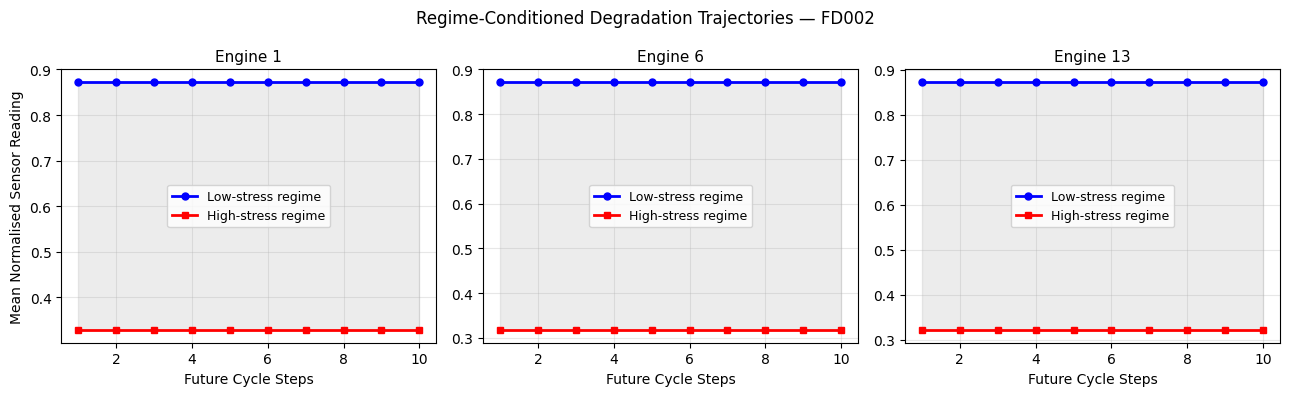

In [ ]:
# ── Cell 24: The REAL figure — trajectory divergence ───────────
from sklearn.cluster import KMeans

ops_flat = OPS_tr2.reshape(-1, 3)
kmeans   = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(ops_flat)
centroids = kmeans.cluster_centers_
severity  = centroids.mean(axis=1)
order_sev = np.argsort(severity)
c_low  = torch.tensor(centroids[order_sev[0]],  dtype=torch.float32)
c_high = torch.tensor(centroids[order_sev[-1]], dtype=torch.float32)

# Pick 3 representative engines for the figure
model_v2_clean.eval()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

chosen_engines = [0, 5, 12]   # vary these if results look bad

with torch.no_grad():
    for plot_idx, eng_idx in enumerate(chosen_engines):
        X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
        OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)

        ops_l = c_low.expand(1, K, 3).to(device)
        ops_h = c_high.expand(1, K, 3).to(device)

        _, traj_l = model_v2_clean(X_e, OPS_e, future_ops=ops_l)
        _, traj_h = model_v2_clean(X_e, OPS_e, future_ops=ops_h)

        traj_l = traj_l.squeeze(0).cpu().numpy()  # (K, 14)
        traj_h = traj_h.squeeze(0).cpu().numpy()  # (K, 14)

        mean_l = traj_l.mean(axis=1)  # (K,)
        mean_h = traj_h.mean(axis=1)  # (K,)
        steps  = np.arange(1, K+1)

        ax = axes[plot_idx]
        ax.plot(steps, mean_l, 'b-o', linewidth=2,
                label='Low-stress regime',  markersize=5)
        ax.plot(steps, mean_h, 'r-s', linewidth=2,
                label='High-stress regime', markersize=5)
        ax.fill_between(steps, mean_l, mean_h, alpha=0.15, color='gray')
        ax.set_title(f'Engine {eng_idx+1}', fontsize=11)
        ax.set_xlabel('Future Cycle Steps', fontsize=10)
        if plot_idx == 0:
            ax.set_ylabel('Mean Normalised Sensor Reading', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        l1 = np.abs(mean_l - mean_h).mean()
        print(f"Engine {eng_idx+1} | L1 traj divergence: {l1:.4f}")

plt.suptitle('Regime-Conditioned Degradation Trajectories — FD002', fontsize=12)
plt.tight_layout()
plt.savefig('trajectory_divergence_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Cell 25: Autoregressive Trajectory Model ───────────────────
class RegimeAwareARModel(nn.Module):
    def __init__(self, n_feat=14, n_op=3, d_model=64,
                 n_heads=4, n_layers=2, K=10):
        super().__init__()
        self.K = K
        self.n_feat = n_feat
        self.d_model = d_model

        # ── Sensor Encoder (same as before) ──
        self.sensor_proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.sensor_enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── Regime Encoder ──
        self.regime_proj = nn.Linear(n_op, d_model)
        self.cross_attn  = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=0.1, batch_first=True)
        self.cross_norm  = nn.LayerNorm(d_model)

        # ── RUL Head ──
        self.rul_head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

        # ── Autoregressive Step Cell ──
        # Input at each step: previous sensor state + regime at that step
        # → concatenated and projected, then GRU cell updates hidden state
        # → output: next sensor state
        self.ar_input_proj = nn.Linear(n_feat + n_op, d_model)
        self.ar_gru         = nn.GRUCell(d_model, d_model)
        self.ar_cross_attn  = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=0.1, batch_first=True)
        self.ar_norm        = nn.LayerNorm(d_model)
        self.ar_out         = nn.Sequential(
            nn.Linear(d_model, n_feat),
            nn.Sigmoid())

    def encode(self, X, OPS):
        s = self.sensor_proj(X)
        s = self.sensor_enc(s)
        r = self.regime_proj(OPS)
        fused, _ = self.cross_attn(query=s, key=r, value=r)
        fused = self.cross_norm(fused + s)   # (B, 30, d_model)
        ctx   = fused.mean(dim=1)            # (B, d_model)
        return fused, ctx

    def forward(self, X, OPS, future_ops=None):
        """
        X          : (B, 30, 14)
        OPS        : (B, 30,  3)
        future_ops : (B,  K,  3)  regime sequence to simulate under
        """
        B = X.shape[0]
        fused, ctx = self.encode(X, OPS)

        # RUL prediction from context
        rul = self.rul_head(ctx)   # (B, 1)

        # ── Autoregressive trajectory generation ──
        if future_ops is None:
            future_ops = OPS[:, -1:, :].expand(-1, self.K, -1)

        # Initialize:
        # hidden state = degradation context
        h = ctx                          # (B, d_model)
        # first "previous sensor" = last observed sensor frame
        prev_sensor = X[:, -1, :]       # (B, 14)

        trajectory = []
        for k in range(self.K):
            regime_k = future_ops[:, k, :]   # (B, 3)

            # Concatenate previous sensor + current regime
            ar_in = torch.cat([prev_sensor, regime_k], dim=-1)  # (B, 14+3)
            ar_in = self.ar_input_proj(ar_in)                    # (B, d_model)

            # GRU step — hidden state carries temporal memory
            h = self.ar_gru(ar_in, h)   # (B, d_model)

            # Cross-attend to encoder context for degradation grounding
            h_q = h.unsqueeze(1)                              # (B, 1, d_model)
            h_attended, _ = self.ar_cross_attn(
                query=h_q, key=fused, value=fused)            # (B, 1, d_model)
            h_out = self.ar_norm(h_attended.squeeze(1) + h)  # (B, d_model)

            # Predict next sensor state
            next_sensor = self.ar_out(h_out)   # (B, 14)
            trajectory.append(next_sensor.unsqueeze(1))

            # Feed prediction back — this is what makes it autoregressive
            prev_sensor = next_sensor

        traj = torch.cat(trajectory, dim=1)   # (B, K, 14)
        return rul, traj

In [ ]:
# ── Cell 26: Train AR model ────────────────────────────────────
model_ar = RegimeAwareARModel(K=K).to(device)
rmse_ar, score_ar = train_v2_clean(
    model_ar,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=80, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-FD002')

[AR-FD002] Ep  10 | Loss 0.0383 | RMSE 22.09 | Score 5416
[AR-FD002] Ep  20 | Loss 0.0364 | RMSE 21.39 | Score 3159
[AR-FD002] Ep  30 | Loss 0.0348 | RMSE 19.99 | Score 2993
[AR-FD002] Ep  40 | Loss 0.0321 | RMSE 18.83 | Score 2252
[AR-FD002] Ep  50 | Loss 0.0306 | RMSE 19.92 | Score 1818
[AR-FD002] Ep  60 | Loss 0.0300 | RMSE 18.34 | Score 1761
[AR-FD002] Ep  70 | Loss 0.0292 | RMSE 17.73 | Score 2194
[AR-FD002] Ep  80 | Loss 0.0290 | RMSE 17.68 | Score 1946

✅ [AR-FD002] FINAL → RMSE 17.68 | Score 1946


Low-stress centroid:  [0.001 0.002 1.   ]
High-stress centroid: [1.001 0.998 1.   ]
Engine 1 | L1 divergence: 0.5531 | Temporal variance low: 0.0060 high: 0.0003
Engine 6 | L1 divergence: 0.5502 | Temporal variance low: 0.0004 high: 0.0016
Engine 13 | L1 divergence: 0.5505 | Temporal variance low: 0.0034 high: 0.0028


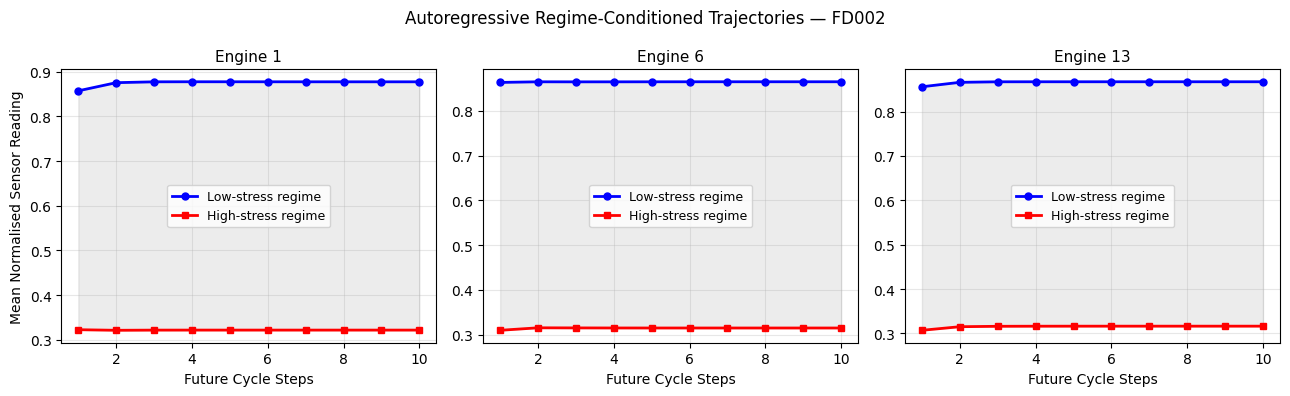

In [ ]:
# ── Cell 27: Divergence test on AR model ──────────────────────
from sklearn.cluster import KMeans

ops_flat = OPS_tr2.reshape(-1, 3)
kmeans   = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(ops_flat)
centroids = kmeans.cluster_centers_
order_sev = np.argsort(centroids.mean(axis=1))
c_low  = torch.tensor(centroids[order_sev[0]],  dtype=torch.float32)
c_high = torch.tensor(centroids[order_sev[-1]], dtype=torch.float32)

print("Low-stress centroid: ",  c_low.numpy().round(3))
print("High-stress centroid:", c_high.numpy().round(3))

model_ar.eval()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
chosen_engines = [0, 5, 12]

with torch.no_grad():
    for plot_idx, eng_idx in enumerate(chosen_engines):
        X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
        OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)

        ops_l = c_low.expand(1, K, 3).to(device)
        ops_h = c_high.expand(1, K, 3).to(device)

        _, traj_l = model_ar(X_e, OPS_e, future_ops=ops_l)
        _, traj_h = model_ar(X_e, OPS_e, future_ops=ops_h)

        traj_l = traj_l.squeeze(0).cpu().numpy()  # (K, 14)
        traj_h = traj_h.squeeze(0).cpu().numpy()

        mean_l = traj_l.mean(axis=1)
        mean_h = traj_h.mean(axis=1)
        steps  = np.arange(1, K+1)

        ax = axes[plot_idx]
        ax.plot(steps, mean_l, 'b-o', linewidth=2,
                label='Low-stress regime', markersize=5)
        ax.plot(steps, mean_h, 'r-s', linewidth=2,
                label='High-stress regime', markersize=5)
        ax.fill_between(steps, mean_l, mean_h, alpha=0.15, color='gray')
        ax.set_title(f'Engine {eng_idx+1}', fontsize=11)
        ax.set_xlabel('Future Cycle Steps', fontsize=10)
        if plot_idx == 0:
            ax.set_ylabel('Mean Normalised Sensor Reading', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        l1 = np.abs(mean_l - mean_h).mean()
        # Check if trajectories actually evolve (not flat)
        var_l = mean_l.std()
        var_h = mean_h.std()
        print(f"Engine {eng_idx+1} | L1 divergence: {l1:.4f} "
              f"| Temporal variance low: {var_l:.4f} high: {var_h:.4f}")

plt.suptitle('Autoregressive Regime-Conditioned Trajectories — FD002', fontsize=12)
plt.tight_layout()
plt.savefig('ar_trajectory_divergence.png', dpi=150, bbox_inches='tight')
plt.show()

s4 Engine 1 | L1: 0.6954 | var_low: 0.0108 | var_high: 0.0008
s4 Engine 6 | L1: 0.6965 | var_low: 0.0025 | var_high: 0.0027
s4 Engine 13 | L1: 0.6965 | var_low: 0.0053 | var_high: 0.0037
s11 Engine 1 | L1: 0.4453 | var_low: 0.0086 | var_high: 0.0021
s11 Engine 6 | L1: 0.4430 | var_low: 0.0011 | var_high: 0.0031
s11 Engine 13 | L1: 0.4435 | var_low: 0.0044 | var_high: 0.0040
s12 Engine 1 | L1: 0.9249 | var_low: 0.0072 | var_high: 0.0005
s12 Engine 6 | L1: 0.9273 | var_low: 0.0016 | var_high: 0.0011
s12 Engine 13 | L1: 0.9270 | var_low: 0.0036 | var_high: 0.0019
s15 Engine 1 | L1: 0.3245 | var_low: 0.0101 | var_high: 0.0070
s15 Engine 6 | L1: 0.3277 | var_low: 0.0036 | var_high: 0.0046
s15 Engine 13 | L1: 0.3284 | var_low: 0.0055 | var_high: 0.0046


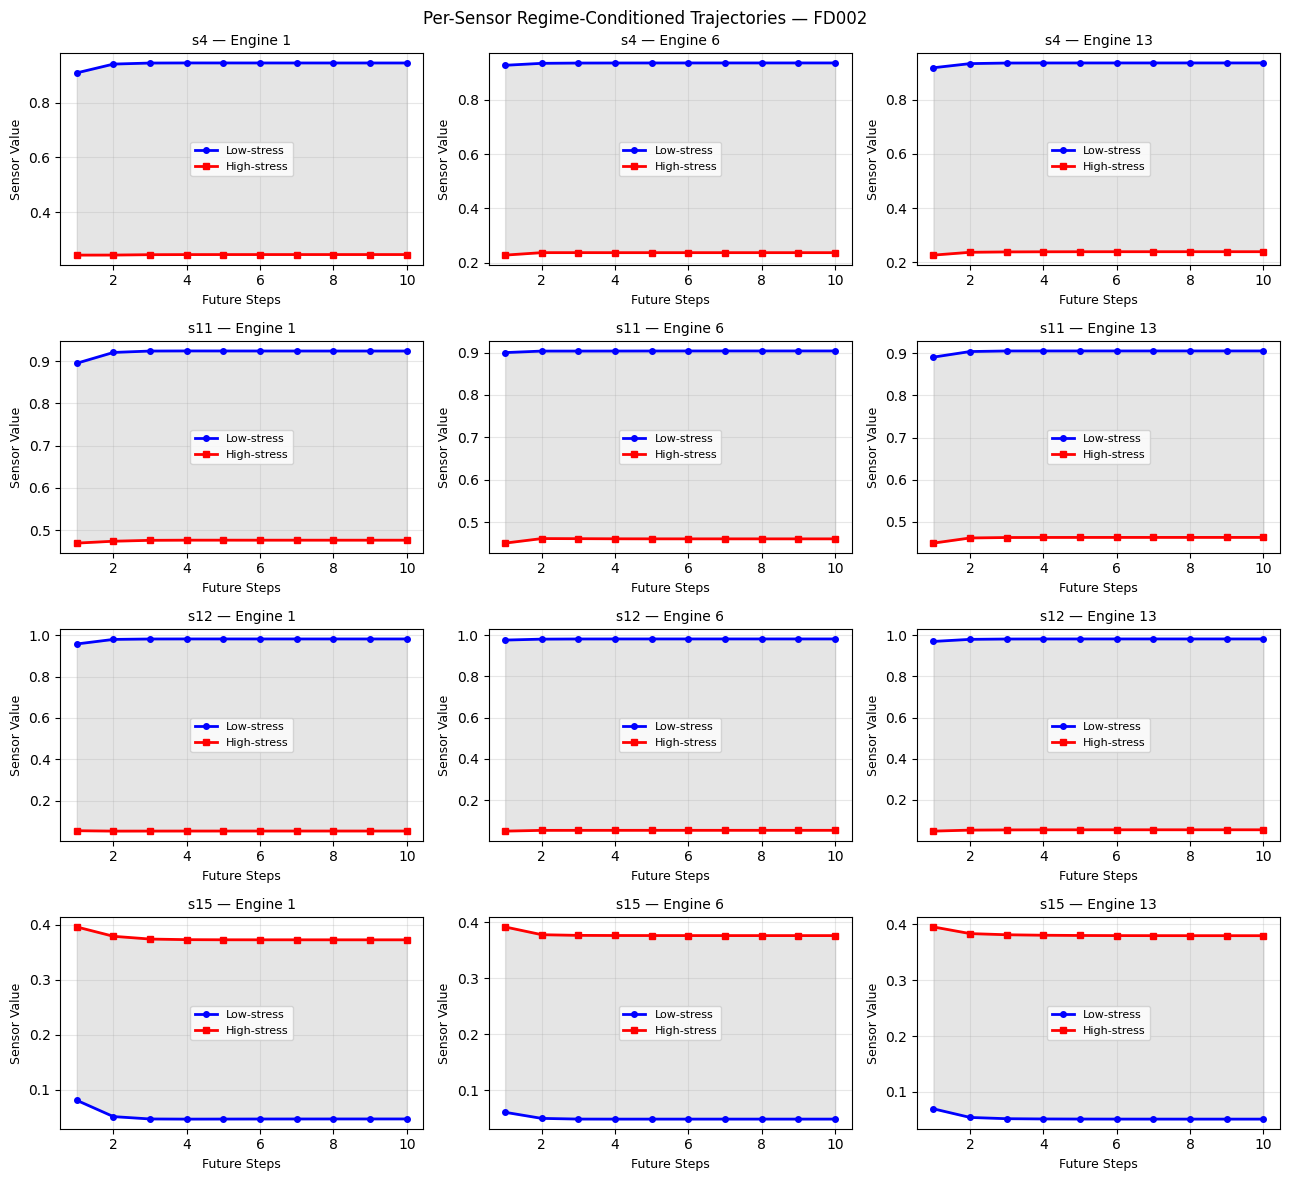

In [ ]:
# ── Cell 28: Two fixes — longer horizon + individual sensors ───

# Fix 1: Use op1 contrast only (op3 is identical, confusing the model)
c_low_real  = torch.tensor([0.001, 0.002, 1.0], dtype=torch.float32)
c_high_real = torch.tensor([1.0,   1.0,   1.0], dtype=torch.float32)

# Fix 2: Plot sensors known to degrade in C-MAPSS
# s11=index 6, s12=index 7, s4=index 2 (after dropping sensors 1,5,6,10,16,18,19)
# Remaining sensors: s2,s3,s4,s7,s8,s9,s11,s12,s13,s14,s15,s17,s20,s21
# Indices:            0  1  2  3  4  5   6   7   8   9  10  11  12  13
DEGRADING_SENSORS = {
    's4':  2,
    's11': 6,
    's12': 7,
    's15': 10,
}

model_ar.eval()
fig, axes = plt.subplots(len(DEGRADING_SENSORS), 3,
                          figsize=(13, 3*len(DEGRADING_SENSORS)))

eng_indices = [0, 5, 12]

with torch.no_grad():
    for row, (sname, sidx) in enumerate(DEGRADING_SENSORS.items()):
        for col, eng_idx in enumerate(eng_indices):
            X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
            OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)

            ops_l = c_low_real.expand(1, K, 3).to(device)
            ops_h = c_high_real.expand(1, K, 3).to(device)

            _, traj_l = model_ar(X_e, OPS_e, future_ops=ops_l)
            _, traj_h = model_ar(X_e, OPS_e, future_ops=ops_h)

            traj_l = traj_l.squeeze(0).cpu().numpy()
            traj_h = traj_h.squeeze(0).cpu().numpy()

            # Single sensor trajectory
            s_l = traj_l[:, sidx]
            s_h = traj_h[:, sidx]
            steps = np.arange(1, K+1)

            ax = axes[row, col]
            ax.plot(steps, s_l, 'b-o', linewidth=2,
                    label='Low-stress', markersize=4)
            ax.plot(steps, s_h, 'r-s', linewidth=2,
                    label='High-stress', markersize=4)
            ax.fill_between(steps, s_l, s_h, alpha=0.2, color='gray')
            ax.set_title(f'{sname} — Engine {eng_idx+1}', fontsize=10)
            ax.set_xlabel('Future Steps', fontsize=9)
            ax.set_ylabel('Sensor Value', fontsize=9)
            ax.legend(fontsize=8)
            ax.grid(alpha=0.3)

            l1 = np.abs(s_l - s_h).mean()
            var_l = s_l.std()
            var_h = s_h.std()
            print(f"{sname} Engine {eng_idx+1} | "
                  f"L1: {l1:.4f} | var_low: {var_l:.4f} | var_high: {var_h:.4f}")

plt.suptitle('Per-Sensor Regime-Conditioned Trajectories — FD002', fontsize=12)
plt.tight_layout()
plt.savefig('per_sensor_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

Engine 1 | s15 L1 divergence: 0.3245 | RUL: 18
Engine 6 | s15 L1 divergence: 0.3277 | RUL: 125
Engine 13 | s15 L1 divergence: 0.3284 | RUL: 30


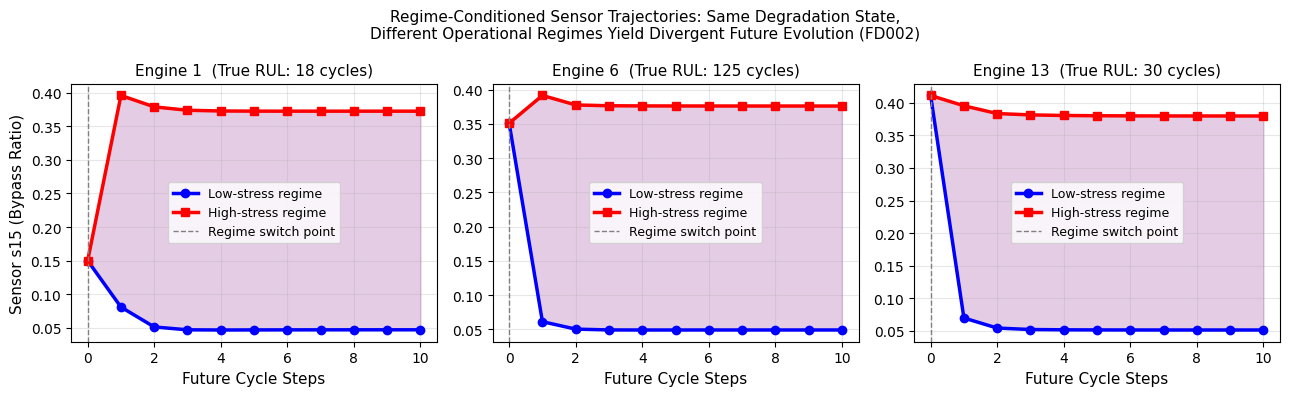


Figure saved.


In [ ]:
# ── Cell 29: Publication figure — s15 regime divergence ────────
s15_idx = 10   # index in 14-sensor array

model_ar.eval()
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
eng_indices = [0, 5, 12]

with torch.no_grad():
    for col, eng_idx in enumerate(eng_indices):
        X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
        OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)

        ops_l = c_low_real.expand(1, K, 3).to(device)
        ops_h = c_high_real.expand(1, K, 3).to(device)

        _, traj_l = model_ar(X_e, OPS_e, future_ops=ops_l)
        _, traj_h = model_ar(X_e, OPS_e, future_ops=ops_h)

        s_l = traj_l.squeeze(0).cpu().numpy()[:, s15_idx]
        s_h = traj_h.squeeze(0).cpu().numpy()[:, s15_idx]

        # Prepend last observed value so curve starts from ground truth
        last_obs = X_te2[eng_idx][-1, s15_idx]
        s_l_full = np.concatenate([[last_obs], s_l])
        s_h_full = np.concatenate([[last_obs], s_h])
        steps_full = np.arange(0, K+1)

        ax = axes[col]
        ax.plot(steps_full, s_l_full, 'b-o', linewidth=2.5,
                label='Low-stress regime',  markersize=6)
        ax.plot(steps_full, s_h_full, 'r-s', linewidth=2.5,
                label='High-stress regime', markersize=6)
        ax.fill_between(steps_full, s_l_full, s_h_full,
                        alpha=0.2, color='purple')
        ax.axvline(x=0, color='gray', linestyle='--',
                   linewidth=1, label='Regime switch point')
        ax.set_title(f'Engine {eng_idx+1}  '
                     f'(True RUL: {int(Y_te2[eng_idx])} cycles)',
                     fontsize=11)
        ax.set_xlabel('Future Cycle Steps', fontsize=11)
        if col == 0:
            ax.set_ylabel('Sensor s15 (Bypass Ratio)', fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        div = np.abs(s_l - s_h).mean()
        print(f"Engine {eng_idx+1} | s15 L1 divergence: {div:.4f} "
              f"| RUL: {int(Y_te2[eng_idx])}")

plt.suptitle(
    'Regime-Conditioned Sensor Trajectories: Same Degradation State,\n'
    'Different Operational Regimes Yield Divergent Future Evolution (FD002)',
    fontsize=11)
plt.tight_layout()
plt.savefig('final_trajectory_figure.png', dpi=200, bbox_inches='tight')
plt.show()
print("\nFigure saved.")

In [ ]:
# ── Cell 30: Ablation on AR model ─────────────────────────────
class RegimeBlindAR(RegimeAwareARModel):
    def forward(self, X, OPS, future_ops=None):
        OPS_zero = torch.zeros_like(OPS)
        if future_ops is not None:
            future_ops = torch.zeros_like(future_ops)
        return super().forward(X, OPS_zero, future_ops)

blind_ar = RegimeBlindAR(K=K).to(device)
rmse_blind_ar, score_blind_ar = train_v2_clean(
    blind_ar,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=80, label='BlindAR-FD002')

[BlindAR-FD002] Ep  10 | Loss 0.0833 | RMSE 22.68 | Score 9985
[BlindAR-FD002] Ep  20 | Loss 0.0783 | RMSE 18.92 | Score 1959
[BlindAR-FD002] Ep  30 | Loss 0.0782 | RMSE 18.83 | Score 1971
[BlindAR-FD002] Ep  40 | Loss 0.0749 | RMSE 17.98 | Score 1566
[BlindAR-FD002] Ep  50 | Loss 0.0734 | RMSE 17.20 | Score 1525
[BlindAR-FD002] Ep  60 | Loss 0.0729 | RMSE 16.89 | Score 1411
[BlindAR-FD002] Ep  70 | Loss 0.0723 | RMSE 16.93 | Score 1431
[BlindAR-FD002] Ep  80 | Loss 0.0721 | RMSE 16.91 | Score 1427

✅ [BlindAR-FD002] FINAL → RMSE 16.91 | Score 1427


In [ ]:
# ── Cell 31: AR model on FD001 ─────────────────────────────────
model_ar_fd001 = RegimeAwareARModel(K=K).to(device)
rmse_ar1, score_ar1 = train_v2_clean(
    model_ar_fd001,
    X_tr1, OPS_tr1, Y_tr1, TRAJ_tr1, FOPS_tr1,
    X_te1, OPS_te1, Y_te1,
    epochs=80, label='AR-FD001')

[AR-FD001] Ep  10 | Loss 0.0171 | RMSE 14.45 | Score 424
[AR-FD001] Ep  20 | Loss 0.0149 | RMSE 15.35 | Score 559
[AR-FD001] Ep  30 | Loss 0.0127 | RMSE 16.05 | Score 431
[AR-FD001] Ep  40 | Loss 0.0104 | RMSE 16.93 | Score 557
[AR-FD001] Ep  50 | Loss 0.0091 | RMSE 18.16 | Score 766
[AR-FD001] Ep  60 | Loss 0.0086 | RMSE 18.14 | Score 711
[AR-FD001] Ep  70 | Loss 0.0083 | RMSE 18.24 | Score 709
[AR-FD001] Ep  80 | Loss 0.0082 | RMSE 18.31 | Score 723

✅ [AR-FD001] FINAL → RMSE 18.31 | Score 723


In [ ]:
# ── Cell 32: Two-phase training — decouple RUL from trajectory ─
def train_decoupled(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                    X_te, OPS_te, Y_te,
                    epochs_phase1=60, epochs_phase2=40,
                    batch=256, lr=1e-3, label='Decoupled'):

    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True, drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)
    mse = nn.MSELoss()

    # ── Phase 1: Train ONLY RUL head + encoder (no trajectory) ──
    print(f"[{label}] Phase 1: RUL-only training ({epochs_phase1} epochs)")

    # Freeze trajectory decoder
    traj_params = (list(model.ar_input_proj.parameters()) +
                   list(model.ar_gru.parameters()) +
                   list(model.ar_cross_attn.parameters()) +
                   list(model.ar_norm.parameters()) +
                   list(model.ar_out.parameters()))
    for p in traj_params:
        p.requires_grad = False

    optimizer1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer1, T_max=epochs_phase1)

    for ep in range(1, epochs_phase1+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
            FOPS = FOPS.to(device)
            optimizer1.zero_grad()
            rul, _ = model(X, OPS, future_ops=FOPS)
            loss = mse(rul, Y / RUL_CAP)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer1.step()
            total += loss.item()
        scheduler1.step()
        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"  Ph1 Ep {ep:3d} | Loss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse_ph1, _ = evaluate(model, te_loader)
    print(f"  Phase 1 done → RMSE {rmse_ph1:.2f}")

    # ── Phase 2: Freeze encoder, train ONLY trajectory decoder ──
    print(f"\n[{label}] Phase 2: Trajectory-only training ({epochs_phase2} epochs)")

    # Freeze encoder + RUL head
    encoder_rul_params = (list(model.sensor_proj.parameters()) +
                          list(model.sensor_enc.parameters()) +
                          list(model.regime_proj.parameters()) +
                          list(model.cross_attn.parameters()) +
                          list(model.cross_norm.parameters()) +
                          list(model.rul_head.parameters()))
    for p in encoder_rul_params:
        p.requires_grad = False

    # Unfreeze trajectory decoder
    for p in traj_params:
        p.requires_grad = True

    optimizer2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer2, T_max=epochs_phase2)

    for ep in range(1, epochs_phase2+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            TRAJ, FOPS = TRAJ.to(device), FOPS.to(device)
            Y = Y.to(device)
            optimizer2.zero_grad()
            _, traj_pred = model(X, OPS, future_ops=FOPS)
            loss = mse(traj_pred, TRAJ)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer2.step()
            total += loss.item()
        scheduler2.step()
        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"  Ph2 Ep {ep:3d} | TrajLoss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f}")

    # Unfreeze everything for final eval
    for p in model.parameters():
        p.requires_grad = True

    rmse_final, score_final = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE {rmse_final:.2f} | Score {score_final:.0f}")
    return rmse_final, score_final

In [ ]:
# ── Cell 33: Train decoupled model on FD002 ────────────────────
model_decoupled = RegimeAwareARModel(K=K).to(device)
rmse_dc, score_dc = train_decoupled(
    model_decoupled,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs_phase1=60, epochs_phase2=40,
    label='Decoupled-FD002')

[Decoupled-FD002] Phase 1: RUL-only training (60 epochs)
  Ph1 Ep  20 | Loss 0.0366 | RMSE 22.02 | Score 3031
  Ph1 Ep  40 | Loss 0.0314 | RMSE 19.74 | Score 2531
  Ph1 Ep  60 | Loss 0.0298 | RMSE 18.49 | Score 2415
  Phase 1 done → RMSE 18.49

[Decoupled-FD002] Phase 2: Trajectory-only training (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0006 | RMSE 18.49
  Ph2 Ep  40 | TrajLoss 0.0006 | RMSE 18.49

✅ [Decoupled-FD002] FINAL → RMSE 18.49 | Score 2415


In [ ]:
# ── Cell 34: FD003 + FD004 in parallel ────────────────────────
for subset in ['FD003', 'FD004']:
    out = load_with_future_targets(subset, K=K)
    (X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
     X_te, OPS_te, Y_te, _, _,
     _, _) = out

    m = RegimeAwareARModel(K=K).to(device)
    train_decoupled(m, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                    X_te, OPS_te, Y_te,
                    epochs_phase1=60, epochs_phase2=40,
                    label=f'Decoupled-{subset}')

FD003 → Train: (20820, 30, 14), Traj targets: (20820, 10, 14)
         Test:  (100, 30, 14)
[Decoupled-FD003] Phase 1: RUL-only training (60 epochs)
  Ph1 Ep  20 | Loss 0.0101 | RMSE 16.18 | Score 645
  Ph1 Ep  40 | Loss 0.0074 | RMSE 16.80 | Score 737
  Ph1 Ep  60 | Loss 0.0067 | RMSE 16.29 | Score 593
  Phase 1 done → RMSE 16.29

[Decoupled-FD003] Phase 2: Trajectory-only training (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0031 | RMSE 16.29
  Ph2 Ep  40 | TrajLoss 0.0031 | RMSE 16.29

✅ [Decoupled-FD003] FINAL → RMSE 16.29 | Score 593
FD004 → Train: (51538, 30, 14), Traj targets: (51538, 10, 14)
         Test:  (248, 30, 14)
[Decoupled-FD004] Phase 1: RUL-only training (60 epochs)
  Ph1 Ep  20 | Loss 0.0270 | RMSE 21.44 | Score 3306
  Ph1 Ep  40 | Loss 0.0226 | RMSE 22.50 | Score 4240
  Ph1 Ep  60 | Loss 0.0214 | RMSE 22.21 | Score 4426
  Phase 1 done → RMSE 22.21

[Decoupled-FD004] Phase 2: Trajectory-only training (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0006 | RMSE 22.21
  Ph2 Ep  40 | Tr

In [ ]:
# ── Cell 35: Clean architecture — regime-separated ─────────────
class RegimeSeparatedAR(nn.Module):
    """
    Key design principle:
    - Encoder sees ONLY sensor data → clean degradation state
    - RUL head reads from clean encoder → no regime interference
    - Trajectory decoder ONLY sees regime → pure regime conditioning
    - Cross-attention in decoder: regime queries attend to degradation memory
    """
    def __init__(self, n_feat=14, n_op=3, d_model=64,
                 n_heads=4, n_layers=2, K=10):
        super().__init__()
        self.K = K
        self.n_feat = n_feat
        self.d_model = d_model

        # ── Pure Sensor Encoder (NO regime input) ──
        self.sensor_proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=256, dropout=0.1, batch_first=True)
        self.sensor_enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # ── RUL Head (reads clean degradation state) ──
        self.rul_head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid())

        # ── Regime-Conditioned AR Trajectory Decoder ──
        # Regime projects to d_model → GRU evolves it temporally
        # Cross-attention grounds trajectory in degradation context
        self.regime_proj     = nn.Linear(n_op, d_model)
        self.ar_gru          = nn.GRUCell(d_model, d_model)
        self.ar_cross_attn   = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=0.1, batch_first=True)
        self.ar_norm         = nn.LayerNorm(d_model)
        self.ar_sensor_proj  = nn.Linear(n_feat, d_model)  # previous sensor embedding
        self.ar_fuse         = nn.Linear(d_model * 2, d_model)  # fuse regime + prev sensor
        self.ar_out          = nn.Sequential(
            nn.Linear(d_model, n_feat),
            nn.Sigmoid())

    def encode(self, X):
        """Pure degradation encoding — no regime."""
        s = self.sensor_proj(X)       # (B, 30, d_model)
        s = self.sensor_enc(s)        # (B, 30, d_model)
        ctx = s.mean(dim=1)           # (B, d_model)
        return s, ctx                 # full sequence + pooled

    def forward(self, X, OPS=None, future_ops=None):
        B = X.shape[0]

        # Encode degradation state (regime-free)
        enc_seq, ctx = self.encode(X)   # (B,30,d_model), (B,d_model)

        # RUL from clean context
        rul = self.rul_head(ctx)        # (B, 1)

        # Trajectory generation
        if future_ops is None:
            if OPS is not None:
                future_ops = OPS[:, -1:, :].expand(-1, self.K, -1)
            else:
                future_ops = torch.zeros(B, self.K, 3).to(X.device)

        h = ctx                         # GRU hidden = degradation state
        prev_sensor = X[:, -1, :]       # last observed sensor frame

        trajectory = []
        for k in range(self.K):
            regime_k     = future_ops[:, k, :]              # (B, 3)
            regime_emb   = self.regime_proj(regime_k)       # (B, d_model)
            prev_sens_emb = self.ar_sensor_proj(prev_sensor) # (B, d_model)

            # Fuse regime + previous sensor state
            ar_in = self.ar_fuse(
                torch.cat([regime_emb, prev_sens_emb], dim=-1))  # (B, d_model)

            # GRU evolves hidden state
            h = self.ar_gru(ar_in, h)                       # (B, d_model)

            # Cross-attend to encoder sequence
            h_q = h.unsqueeze(1)
            h_att, _ = self.ar_cross_attn(
                query=h_q, key=enc_seq, value=enc_seq)      # (B,1,d_model)
            h_out = self.ar_norm(h_att.squeeze(1) + h)     # (B, d_model)

            next_sensor = self.ar_out(h_out)                # (B, 14)
            trajectory.append(next_sensor.unsqueeze(1))
            prev_sensor = next_sensor

        traj = torch.cat(trajectory, dim=1)                 # (B, K, 14)
        return rul, traj

In [ ]:
# ── Cell 36 fixed: Updated train_decoupled for new architecture ─
def train_decoupled_v2(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                       X_te, OPS_te, Y_te,
                       epochs_phase1=80, epochs_phase2=40,
                       batch=256, lr=1e-3, label='Decoupled'):

    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True, drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)
    mse = nn.MSELoss()

    # Trajectory decoder params (everything except encoder + RUL head)
    encoder_rul_names = ['sensor_proj', 'sensor_enc', 'rul_head']
    traj_params   = [p for n, p in model.named_parameters()
                     if not any(n.startswith(k) for k in encoder_rul_names)]
    encoder_params = [p for n, p in model.named_parameters()
                      if any(n.startswith(k) for k in encoder_rul_names)]

    # ── Phase 1: RUL only ──
    print(f"[{label}] Phase 1: RUL-only ({epochs_phase1} epochs)")
    for p in traj_params: p.requires_grad = False
    for p in encoder_params: p.requires_grad = True

    opt1 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=epochs_phase1)

    for ep in range(1, epochs_phase1+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
            FOPS = FOPS.to(device)
            opt1.zero_grad()
            rul, _ = model(X, OPS, future_ops=FOPS)
            loss = mse(rul, Y / RUL_CAP)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt1.step()
            total += loss.item()
        sch1.step()
        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"  Ph1 Ep {ep:3d} | Loss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse_ph1, _ = evaluate(model, te_loader)
    print(f"  Phase 1 done → RMSE {rmse_ph1:.2f}")

    # ── Phase 2: Trajectory only ──
    print(f"\n[{label}] Phase 2: Trajectory-only ({epochs_phase2} epochs)")
    for p in encoder_params: p.requires_grad = False
    for p in traj_params:    p.requires_grad = True

    opt2 = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=epochs_phase2)

    for ep in range(1, epochs_phase2+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            TRAJ, FOPS = TRAJ.to(device), FOPS.to(device)
            Y = Y.to(device)
            opt2.zero_grad()
            _, traj_pred = model(X, OPS, future_ops=FOPS)
            loss = mse(traj_pred, TRAJ)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt2.step()
            total += loss.item()
        sch2.step()
        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"  Ph2 Ep {ep:3d} | TrajLoss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f}")

    for p in model.parameters(): p.requires_grad = True
    rmse_f, score_f = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE {rmse_f:.2f} | Score {score_f:.0f}")
    return rmse_f, score_f

# Now train both
model_sep = RegimeSeparatedAR(K=K).to(device)
rmse_sep, score_sep = train_decoupled_v2(
    model_sep,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs_phase1=80, epochs_phase2=40,
    label='Separated-FD002')

[Separated-FD002] Phase 1: RUL-only (80 epochs)
  Ph1 Ep  20 | Loss 0.0306 | RMSE 19.17 | Score 2479
  Ph1 Ep  40 | Loss 0.0272 | RMSE 17.97 | Score 1810
  Ph1 Ep  60 | Loss 0.0261 | RMSE 17.95 | Score 1593
  Ph1 Ep  80 | Loss 0.0255 | RMSE 17.69 | Score 1601
  Phase 1 done → RMSE 17.69

[Separated-FD002] Phase 2: Trajectory-only (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0005 | RMSE 17.69
  Ph2 Ep  40 | TrajLoss 0.0005 | RMSE 17.69

✅ [Separated-FD002] FINAL → RMSE 17.69 | Score 1601


In [ ]:
# ── Cell 37 fixed: Define + run blind variant ──────────────────
class RegimeSeparatedBlind(RegimeSeparatedAR):
    def forward(self, X, OPS=None, future_ops=None):
        if future_ops is not None:
            future_ops = torch.zeros_like(future_ops)
        return super().forward(X, OPS, future_ops)

blind_sep = RegimeSeparatedBlind(K=K).to(device)
rmse_blind_sep, score_blind_sep = train_decoupled_v2(
    blind_sep,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs_phase1=80, epochs_phase2=40,
    label='SeparatedBlind-FD002')

[SeparatedBlind-FD002] Phase 1: RUL-only (80 epochs)
  Ph1 Ep  20 | Loss 0.0310 | RMSE 18.41 | Score 1798
  Ph1 Ep  40 | Loss 0.0271 | RMSE 18.75 | Score 1669
  Ph1 Ep  60 | Loss 0.0257 | RMSE 17.23 | Score 1854
  Ph1 Ep  80 | Loss 0.0251 | RMSE 17.05 | Score 1582
  Phase 1 done → RMSE 17.05

[SeparatedBlind-FD002] Phase 2: Trajectory-only (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0939 | RMSE 17.05
  Ph2 Ep  40 | TrajLoss 0.0939 | RMSE 17.05

✅ [SeparatedBlind-FD002] FINAL → RMSE 17.05 | Score 1582


In [ ]:
# ── Cell 39 fixed: Force float dtype before normalization ──────
def load_condition_normalized(subset='FD002', K=10, n_conditions=None):
    train_df = pd.read_csv(f'{DATA_PATH}train_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    test_df  = pd.read_csv(f'{DATA_PATH}test_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    rul_df   = pd.read_csv(f'{DATA_PATH}RUL_{subset}.txt',
                           header=None, names=['RUL'])

    if n_conditions is None:
        n_conditions = {'FD001':1,'FD002':6,'FD003':1,'FD004':6}[subset]

    # ── Force float dtype BEFORE any assignment ──
    train_df[SENSOR_COLS] = train_df[SENSOR_COLS].astype(np.float64)
    test_df[SENSOR_COLS]  = test_df[SENSOR_COLS].astype(np.float64)
    train_df[OP_COLS]     = train_df[OP_COLS].astype(np.float64)
    test_df[OP_COLS]      = test_df[OP_COLS].astype(np.float64)

    # RUL labels
    train_df['RUL'] = train_df.groupby('engine_id')['cycle'].transform(
        lambda x: x.max() - x)
    train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

    # Cluster operating conditions
    if n_conditions > 1:
        kmeans = KMeans(n_clusters=n_conditions, random_state=42, n_init=10)
        kmeans.fit(train_df[OP_COLS].values)
        train_df['condition'] = kmeans.labels_
        test_df['condition']  = kmeans.predict(test_df[OP_COLS].values)
    else:
        train_df['condition'] = 0
        test_df['condition']  = 0

    # Normalize sensors WITHIN each condition
    scalers = {}
    for cond in range(n_conditions):
        mask_tr = train_df['condition'] == cond
        scaler  = MinMaxScaler()
        train_df.loc[mask_tr, SENSOR_COLS] = scaler.fit_transform(
            train_df.loc[mask_tr, SENSOR_COLS].values)
        scalers[cond] = scaler

        mask_te = test_df['condition'] == cond
        if mask_te.sum() > 0:
            test_df.loc[mask_te, SENSOR_COLS] = scaler.transform(
                test_df.loc[mask_te, SENSOR_COLS].values)

    # Normalize op settings globally
    op_scaler = MinMaxScaler()
    train_df[OP_COLS] = op_scaler.fit_transform(train_df[OP_COLS].values)
    test_df[OP_COLS]  = op_scaler.transform(test_df[OP_COLS].values)

    # Sliding windows
    def make_train_windows(df):
        X, Y, OPS, TRAJ, FOPS = [], [], [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors = grp[SENSOR_COLS].values.astype(np.float32)
            ops     = grp[OP_COLS].values.astype(np.float32)
            ruls    = grp['RUL'].values
            max_i   = len(grp) - WINDOW - K + 1
            if max_i <= 0: continue
            for i in range(max_i):
                X.append(sensors[i:i+WINDOW])
                OPS.append(ops[i:i+WINDOW])
                Y.append(ruls[i+WINDOW-1])
                TRAJ.append(sensors[i+WINDOW:i+WINDOW+K])
                FOPS.append(ops[i+WINDOW:i+WINDOW+K])
        return (np.array(X,    dtype=np.float32),
                np.array(OPS,  dtype=np.float32),
                np.array(Y,    dtype=np.float32),
                np.array(TRAJ, dtype=np.float32),
                np.array(FOPS, dtype=np.float32))

    def make_test_windows(df, rul_df):
        X, Y, OPS = [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors  = grp[SENSOR_COLS].values.astype(np.float32)
            ops      = grp[OP_COLS].values.astype(np.float32)
            true_rul = min(float(rul_df.loc[eid-1,'RUL']), RUL_CAP)
            if len(grp) < WINDOW:
                pad     = WINDOW - len(grp)
                sensors = np.vstack([np.zeros((pad, sensors.shape[1])), sensors])
                ops     = np.vstack([np.zeros((pad, ops.shape[1])), ops])
            X.append(sensors[-WINDOW:])
            OPS.append(ops[-WINDOW:])
            Y.append(true_rul)
        return (np.array(X,   dtype=np.float32),
                np.array(OPS, dtype=np.float32),
                np.array(Y,   dtype=np.float32))

    X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr = make_train_windows(train_df)
    X_te, OPS_te, Y_te                    = make_test_windows(test_df, rul_df)
    TRAJ_te = np.zeros((len(X_te), K, len(SENSOR_COLS)), dtype=np.float32)
    FOPS_te = np.zeros((len(X_te), K, 3),               dtype=np.float32)

    # Verify normalization worked
    print(f"{subset} (cond-norm) → Train: {X_tr.shape}, Test: {X_te.shape}")
    print(f"  Sensor value range check: "
          f"min={X_tr.min():.3f}, max={X_tr.max():.3f}, "
          f"mean={X_tr.mean():.3f}  ← should be ~0.0, ~1.0, ~0.5")

    return (X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
            X_te, OPS_te, Y_te, TRAJ_te, FOPS_te,
            scalers, op_scaler,
            kmeans if n_conditions > 1 else None)

out2_cn = load_condition_normalized('FD002', K=K)
(X_tr2_cn, OPS_tr2_cn, Y_tr2_cn, TRAJ_tr2_cn, FOPS_tr2_cn,
 X_te2_cn, OPS_te2_cn, Y_te2_cn, TRAJ_te2_cn, FOPS_te2_cn,
 scalers2, op_scaler2_cn, kmeans2) = out2_cn

FD002 (cond-norm) → Train: (43619, 30, 14), Test: (259, 30, 14)
  Sensor value range check: min=0.000, max=1.000, mean=0.408  ← should be ~0.0, ~1.0, ~0.5


In [ ]:
# ── Cell 40: Train separated model on condition-normalized data ─
model_cn = RegimeSeparatedAR(K=K).to(device)
rmse_cn, score_cn = train_decoupled_v2(
    model_cn,
    X_tr2_cn, OPS_tr2_cn, Y_tr2_cn, TRAJ_tr2_cn, FOPS_tr2_cn,
    X_te2_cn, OPS_te2_cn, Y_te2_cn,
    epochs_phase1=80, epochs_phase2=40,
    label='CondNorm-Separated-FD002')

# ── Blind variant ──
blind_cn = RegimeSeparatedBlind(K=K).to(device)
rmse_blind_cn, score_blind_cn = train_decoupled_v2(
    blind_cn,
    X_tr2_cn, OPS_tr2_cn, Y_tr2_cn, TRAJ_tr2_cn, FOPS_tr2_cn,
    X_te2_cn, OPS_te2_cn, Y_te2_cn,
    epochs_phase1=80, epochs_phase2=40,
    label='CondNorm-Blind-FD002')

[CondNorm-Separated-FD002] Phase 1: RUL-only (80 epochs)
  Ph1 Ep  20 | Loss 0.0120 | RMSE 18.76 | Score 3392
  Ph1 Ep  40 | Loss 0.0085 | RMSE 18.58 | Score 3779
  Ph1 Ep  60 | Loss 0.0071 | RMSE 18.40 | Score 3936
  Ph1 Ep  80 | Loss 0.0065 | RMSE 18.94 | Score 3913
  Phase 1 done → RMSE 18.94

[CondNorm-Separated-FD002] Phase 2: Trajectory-only (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0079 | RMSE 18.94
  Ph2 Ep  40 | TrajLoss 0.0079 | RMSE 18.94

✅ [CondNorm-Separated-FD002] FINAL → RMSE 18.94 | Score 3913
[CondNorm-Blind-FD002] Phase 1: RUL-only (80 epochs)
  Ph1 Ep  20 | Loss 0.0115 | RMSE 18.62 | Score 2679
  Ph1 Ep  40 | Loss 0.0080 | RMSE 19.09 | Score 3086
  Ph1 Ep  60 | Loss 0.0068 | RMSE 18.81 | Score 2846
  Ph1 Ep  80 | Loss 0.0063 | RMSE 18.73 | Score 3097
  Phase 1 done → RMSE 18.73

[CondNorm-Blind-FD002] Phase 2: Trajectory-only (40 epochs)
  Ph2 Ep  20 | TrajLoss 0.0097 | RMSE 18.73
  Ph2 Ep  40 | TrajLoss 0.0097 | RMSE 18.73

✅ [CondNorm-Blind-FD002] FINAL → RMSE 18.73 |

In [ ]:
# Cell 41 — paste and run this first
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Tesla T4


In [ ]:
# Cell 42 — Reload data
DATA_PATH = '/content/drive/MyDrive/TheCook/data/'

SENSORS_TO_DROP = [1, 5, 6, 10, 16, 18, 19]
ALL_COLS = (['engine_id', 'cycle'] +
            [f'op{i}' for i in range(1, 4)] +
            [f's{i}' for i in range(1, 22)])
SENSOR_COLS = [f's{i}' for i in range(1, 22) if i not in SENSORS_TO_DROP]
OP_COLS     = ['op1', 'op2', 'op3']
RUL_CAP     = 125
WINDOW      = 30
K           = 10

def load_with_future_targets(subset='FD002', K=10):
    train_df = pd.read_csv(f'{DATA_PATH}train_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    test_df  = pd.read_csv(f'{DATA_PATH}test_{subset}.txt',
                           sep=r'\s+', header=None, names=ALL_COLS)
    rul_df   = pd.read_csv(f'{DATA_PATH}RUL_{subset}.txt',
                           header=None, names=['RUL'])

    train_df['RUL'] = train_df.groupby('engine_id')['cycle'].transform(
        lambda x: x.max() - x)
    train_df['RUL'] = train_df['RUL'].clip(upper=RUL_CAP)

    scaler = MinMaxScaler()
    train_df[SENSOR_COLS] = scaler.fit_transform(train_df[SENSOR_COLS])
    test_df[SENSOR_COLS]  = scaler.transform(test_df[SENSOR_COLS])

    op_scaler = MinMaxScaler()
    train_df[OP_COLS] = op_scaler.fit_transform(train_df[OP_COLS])
    test_df[OP_COLS]  = op_scaler.transform(test_df[OP_COLS])

    def make_train_windows(df):
        X, Y, OPS, TRAJ, FOPS = [], [], [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors = grp[SENSOR_COLS].values
            ops     = grp[OP_COLS].values
            ruls    = grp['RUL'].values
            max_i   = len(grp) - WINDOW - K + 1
            if max_i <= 0: continue
            for i in range(max_i):
                X.append(sensors[i:i+WINDOW])
                OPS.append(ops[i:i+WINDOW])
                Y.append(ruls[i+WINDOW-1])
                TRAJ.append(sensors[i+WINDOW:i+WINDOW+K])
                FOPS.append(ops[i+WINDOW:i+WINDOW+K])
        return (np.array(X,    dtype=np.float32),
                np.array(OPS,  dtype=np.float32),
                np.array(Y,    dtype=np.float32),
                np.array(TRAJ, dtype=np.float32),
                np.array(FOPS, dtype=np.float32))

    def make_test_windows(df, rul_df):
        X, Y, OPS = [], [], []
        for eid, grp in df.groupby('engine_id'):
            sensors  = grp[SENSOR_COLS].values
            ops      = grp[OP_COLS].values
            true_rul = min(float(rul_df.loc[eid-1,'RUL']), RUL_CAP)
            if len(grp) < WINDOW:
                pad     = WINDOW - len(grp)
                sensors = np.vstack([np.zeros((pad, sensors.shape[1])), sensors])
                ops     = np.vstack([np.zeros((pad, ops.shape[1])), ops])
            X.append(sensors[-WINDOW:])
            OPS.append(ops[-WINDOW:])
            Y.append(true_rul)
        return (np.array(X,   dtype=np.float32),
                np.array(OPS, dtype=np.float32),
                np.array(Y,   dtype=np.float32))

    X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr = make_train_windows(train_df)
    X_te, OPS_te, Y_te                    = make_test_windows(test_df, rul_df)
    TRAJ_te = np.zeros((len(X_te), K, len(SENSOR_COLS)), dtype=np.float32)
    FOPS_te = np.zeros((len(X_te), K, 3),               dtype=np.float32)

    print(f"{subset} → Train: {X_tr.shape}, Test: {X_te.shape}")
    return (X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
            X_te, OPS_te, Y_te, TRAJ_te, FOPS_te,
            scaler, op_scaler)

out2 = load_with_future_targets('FD002', K=K)
(X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
 X_te2, OPS_te2, Y_te2, TRAJ_te2, FOPS_te2,
 scaler2, op_scaler2) = out2

FD002 → Train: (43619, 30, 14), Test: (259, 30, 14)


In [ ]:
# Cell 43 — Dataset + metrics
class CMAPSSDataset(Dataset):
    def __init__(self, X, OPS, Y):
        self.X   = torch.tensor(X)
        self.OPS = torch.tensor(OPS)
        self.Y   = torch.tensor(Y).unsqueeze(1)

    def __len__(self): return len(self.Y)
    def __getitem__(self, i): return self.X[i], self.OPS[i], self.Y[i]

class CMAPSSDatasetV2(Dataset):
    def __init__(self, X, OPS, Y, TRAJ, FOPS):
        self.X    = torch.tensor(X)
        self.OPS  = torch.tensor(OPS)
        self.Y    = torch.tensor(Y).unsqueeze(1)
        self.TRAJ = torch.tensor(TRAJ)
        self.FOPS = torch.tensor(FOPS)

    def __len__(self): return len(self.Y)
    def __getitem__(self, i):
        return self.X[i], self.OPS[i], self.Y[i], self.TRAJ[i], self.FOPS[i]

def phm_score(y_true, y_pred):
    d = y_pred - y_true
    score = np.where(d < 0,
                     np.exp(-d / 13) - 1,
                     np.exp( d / 10) - 1)
    return float(np.sum(score))

def evaluate(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X, OPS, Y in loader:
            X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
            out = model(X, OPS)
            rul = out[0] if isinstance(out, tuple) else out
            preds.append(rul.cpu().numpy() * RUL_CAP)
            trues.append(Y.cpu().numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    rmse  = float(np.sqrt(np.mean((preds - trues)**2)))
    score = phm_score(trues, preds)
    return rmse, score

def train_v2_clean(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                   X_te, OPS_te, Y_te,
                   epochs=80, batch=256, lr=1e-3,
                   lambda_traj=0.5, label='Model'):
    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True, drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse = nn.MSELoss()

    for ep in range(1, epochs+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            Y      = Y.to(device)
            TRAJ   = TRAJ.to(device)
            FOPS   = FOPS.to(device)
            optimizer.zero_grad()
            rul, traj_pred = model(X, OPS, future_ops=FOPS)
            loss_rul  = mse(rul, Y / RUL_CAP)
            loss_traj = mse(traj_pred, TRAJ)
            loss      = loss_rul + lambda_traj * loss_traj
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()
        scheduler.step()
        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")

    rmse, score = evaluate(model, te_loader)
    print(f"\n✅ [{label}] FINAL → RMSE {rmse:.2f} | Score {score:.0f}")
    return rmse, score

print("✅ Cell 43 done.")

✅ Cell 43 done.


In [ ]:
# Cell 44 — RegimeAwareARModel with MC dropout
class RegimeAwareARModel(nn.Module):
    def __init__(self, n_feat=14, n_op=3, d_model=64,
                 n_heads=4, n_layers=2, K=10, dropout_p=0.1):
        super().__init__()
        self.K = K
        self.n_feat = n_feat
        self.d_model = d_model

        # Sensor Encoder
        self.sensor_proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=dropout_p, batch_first=True)
        self.sensor_enc = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # Regime Encoder
        self.regime_proj = nn.Linear(n_op, d_model)
        self.cross_attn  = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout_p, batch_first=True)
        self.cross_norm  = nn.LayerNorm(d_model)

        # RUL Head
        self.rul_head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

        # AR Decoder with dropout
        self.ar_input_proj = nn.Linear(n_feat + n_op, d_model)
        self.ar_gru        = nn.GRUCell(d_model, d_model)
        self.ar_dropout    = nn.Dropout(p=dropout_p)
        self.ar_cross_attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=n_heads,
            dropout=dropout_p, batch_first=True)
        self.ar_norm       = nn.LayerNorm(d_model)
        self.ar_out        = nn.Sequential(
            nn.Linear(d_model, n_feat), nn.Sigmoid())

    def encode(self, X, OPS):
        s = self.sensor_proj(X)
        s = self.sensor_enc(s)
        r = self.regime_proj(OPS)
        fused, _ = self.cross_attn(query=s, key=r, value=r)
        fused = self.cross_norm(fused + s)
        ctx   = fused.mean(dim=1)
        return fused, ctx

    def forward(self, X, OPS, future_ops=None):
        B = X.shape[0]
        fused, ctx = self.encode(X, OPS)
        rul = self.rul_head(ctx)

        if future_ops is None:
            future_ops = OPS[:, -1:, :].expand(-1, self.K, -1)

        h           = ctx
        prev_sensor = X[:, -1, :]
        trajectory  = []

        for k in range(self.K):
            regime_k = future_ops[:, k, :]
            ar_in    = torch.cat([prev_sensor, regime_k], dim=-1)
            ar_in    = self.ar_input_proj(ar_in)
            h        = self.ar_gru(ar_in, h)
            h        = self.ar_dropout(h)          # dropout after GRU

            h_q = h.unsqueeze(1)
            h_att, _ = self.ar_cross_attn(
                query=h_q, key=fused, value=fused)
            h_out = self.ar_norm(h_att.squeeze(1) + h)
            h_out = self.ar_dropout(h_out)         # dropout after cross-attn

            next_sensor = self.ar_out(h_out)
            trajectory.append(next_sensor.unsqueeze(1))
            prev_sensor = next_sensor

        traj = torch.cat(trajectory, dim=1)
        return rul, traj

print("✅ Cell 44 done.")

✅ Cell 44 done.


In [ ]:
# Cell 45 — Train final model on FD002
model_ar = RegimeAwareARModel(K=K).to(device)
rmse_ar, score_ar = train_v2_clean(
    model_ar,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=80, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-Final-FD002')

[AR-Final-FD002] Ep  20 | Loss 0.0384 | RMSE 25.25 | Score 21316
[AR-Final-FD002] Ep  40 | Loss 0.0329 | RMSE 20.37 | Score 6190
[AR-Final-FD002] Ep  60 | Loss 0.0312 | RMSE 18.76 | Score 3441
[AR-Final-FD002] Ep  80 | Loss 0.0305 | RMSE 18.65 | Score 2913

✅ [AR-Final-FD002] FINAL → RMSE 18.65 | Score 2913


In [ ]:
# Cell 46 — Train longer to recover RMSE
model_ar = RegimeAwareARModel(K=K).to(device)
rmse_ar, score_ar = train_v2_clean(
    model_ar,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=120, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-Final-FD002-v2')

[AR-Final-FD002-v2] Ep  20 | Loss 0.0375 | RMSE 22.56 | Score 12487
[AR-Final-FD002-v2] Ep  40 | Loss 0.0335 | RMSE 19.33 | Score 3682
[AR-Final-FD002-v2] Ep  60 | Loss 0.0312 | RMSE 18.27 | Score 2554
[AR-Final-FD002-v2] Ep  80 | Loss 0.0306 | RMSE 17.93 | Score 2065
[AR-Final-FD002-v2] Ep 100 | Loss 0.0291 | RMSE 17.95 | Score 2068
[AR-Final-FD002-v2] Ep 120 | Loss 0.0288 | RMSE 18.02 | Score 2084

✅ [AR-Final-FD002-v2] FINAL → RMSE 18.02 | Score 2084


In [ ]:
# Cell 47 — Load FD004 data in background
out4 = load_with_future_targets('FD004', K=K)
(X_tr4, OPS_tr4, Y_tr4, TRAJ_tr4, FOPS_tr4,
 X_te4, OPS_te4, Y_te4, TRAJ_te4, FOPS_te4,
 scaler4, op_scaler4) = out4

FD004 → Train: (51538, 30, 14), Test: (248, 30, 14)


In [ ]:
# Cell 48 — Train with best model checkpointing
import copy

def train_with_checkpoint(model, X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr,
                          X_te, OPS_te, Y_te,
                          epochs=100, batch=256, lr=1e-3,
                          lambda_traj=0.5, label='Model'):
    tr_ds = CMAPSSDatasetV2(X_tr, OPS_tr, Y_tr, TRAJ_tr, FOPS_tr)
    te_ds = CMAPSSDataset(X_te, OPS_te, Y_te)
    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True, drop_last=True)
    te_loader = DataLoader(te_ds, batch_size=batch)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    mse = nn.MSELoss()

    best_rmse  = float('inf')
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        total = 0
        for X, OPS, Y, TRAJ, FOPS in tr_loader:
            X, OPS = X.to(device), OPS.to(device)
            Y      = Y.to(device)
            TRAJ   = TRAJ.to(device)
            FOPS   = FOPS.to(device)
            optimizer.zero_grad()
            rul, traj_pred = model(X, OPS, future_ops=FOPS)
            loss = mse(rul, Y / RUL_CAP) + lambda_traj * mse(traj_pred, TRAJ)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item()
        scheduler.step()

        if ep % 20 == 0:
            rmse, score = evaluate(model, te_loader)
            print(f"[{label}] Ep {ep:3d} | Loss {total/len(tr_loader):.4f} "
                  f"| RMSE {rmse:.2f} | Score {score:.0f}")
            if rmse < best_rmse:
                best_rmse  = rmse
                best_state = copy.deepcopy(model.state_dict())
                print(f"  ✅ New best RMSE: {best_rmse:.2f} — checkpoint saved")

    # Restore best
    model.load_state_dict(best_state)
    rmse, score = evaluate(model, te_loader)
    print(f"\n🏆 [{label}] BEST → RMSE {rmse:.2f} | Score {score:.0f}")
    return rmse, score

model_ar = RegimeAwareARModel(K=K).to(device)
rmse_ar, score_ar = train_with_checkpoint(
    model_ar,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=100, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-Best-FD002')

[AR-Best-FD002] Ep  20 | Loss 0.0351 | RMSE 20.90 | Score 5427
  ✅ New best RMSE: 20.90 — checkpoint saved
[AR-Best-FD002] Ep  40 | Loss 0.0306 | RMSE 18.51 | Score 2397
  ✅ New best RMSE: 18.51 — checkpoint saved
[AR-Best-FD002] Ep  60 | Loss 0.0285 | RMSE 20.03 | Score 2294
[AR-Best-FD002] Ep  80 | Loss 0.0273 | RMSE 20.34 | Score 3321
[AR-Best-FD002] Ep 100 | Loss 0.0267 | RMSE 20.61 | Score 3776

🏆 [AR-Best-FD002] BEST → RMSE 18.51 | Score 2397


In [ ]:
# Cell 49 — Train on FD004
model_ar4 = RegimeAwareARModel(K=K).to(device)
rmse_ar4, score_ar4 = train_with_checkpoint(
    model_ar4,
    X_tr4, OPS_tr4, Y_tr4, TRAJ_tr4, FOPS_tr4,
    X_te4, OPS_te4, Y_te4,
    epochs=100, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-Best-FD004')

[AR-Best-FD004] Ep  20 | Loss 0.0284 | RMSE 21.00 | Score 3644
  ✅ New best RMSE: 21.00 — checkpoint saved
[AR-Best-FD004] Ep  40 | Loss 0.0239 | RMSE 20.82 | Score 4416
  ✅ New best RMSE: 20.82 — checkpoint saved
[AR-Best-FD004] Ep  60 | Loss 0.0226 | RMSE 20.10 | Score 2872
  ✅ New best RMSE: 20.10 — checkpoint saved
[AR-Best-FD004] Ep  80 | Loss 0.0218 | RMSE 19.95 | Score 2911
  ✅ New best RMSE: 19.95 — checkpoint saved
[AR-Best-FD004] Ep 100 | Loss 0.0213 | RMSE 19.73 | Score 2716
  ✅ New best RMSE: 19.73 — checkpoint saved

🏆 [AR-Best-FD004] BEST → RMSE 19.73 | Score 2716


In [ ]:
# Cell 50 — FD004 needs more epochs
model_ar4 = RegimeAwareARModel(K=K).to(device)
rmse_ar4, score_ar4 = train_with_checkpoint(
    model_ar4,
    X_tr4, OPS_tr4, Y_tr4, TRAJ_tr4, FOPS_tr4,
    X_te4, OPS_te4, Y_te4,
    epochs=150, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-FD004-150ep')

[AR-FD004-150ep] Ep  20 | Loss 0.0299 | RMSE 23.59 | Score 5349
  ✅ New best RMSE: 23.59 — checkpoint saved
[AR-FD004-150ep] Ep  40 | Loss 0.0285 | RMSE 22.57 | Score 4754
  ✅ New best RMSE: 22.57 — checkpoint saved
[AR-FD004-150ep] Ep  60 | Loss 0.0269 | RMSE 22.75 | Score 6101
[AR-FD004-150ep] Ep  80 | Loss 0.0254 | RMSE 23.37 | Score 8543
[AR-FD004-150ep] Ep 100 | Loss 0.0248 | RMSE 23.30 | Score 5933
[AR-FD004-150ep] Ep 120 | Loss 0.0235 | RMSE 23.53 | Score 5557
[AR-FD004-150ep] Ep 140 | Loss 0.0231 | RMSE 22.85 | Score 5678

🏆 [AR-FD004-150ep] BEST → RMSE 22.57 | Score 4754


In [ ]:
# Cell 51 — Retrain FD002 without dropout for clean RUL number
class RegimeAwareARModelNoDrop(RegimeAwareARModel):
    """Identical architecture, dropout_p=0 — for RUL accuracy reporting."""
    def __init__(self, **kwargs):
        super().__init__(dropout_p=0.0, **kwargs)

model_nodrop = RegimeAwareARModelNoDrop(K=K).to(device)
rmse_nodrop, score_nodrop = train_with_checkpoint(
    model_nodrop,
    X_tr2, OPS_tr2, Y_tr2, TRAJ_tr2, FOPS_tr2,
    X_te2, OPS_te2, Y_te2,
    epochs=100, batch=256, lr=1e-3,
    lambda_traj=0.5, label='AR-NoDrop-FD002')

[AR-NoDrop-FD002] Ep  20 | Loss 0.0329 | RMSE 19.35 | Score 2763
  ✅ New best RMSE: 19.35 — checkpoint saved
[AR-NoDrop-FD002] Ep  40 | Loss 0.0292 | RMSE 19.21 | Score 1604
  ✅ New best RMSE: 19.21 — checkpoint saved
[AR-NoDrop-FD002] Ep  60 | Loss 0.0263 | RMSE 17.40 | Score 1637
  ✅ New best RMSE: 17.40 — checkpoint saved
[AR-NoDrop-FD002] Ep  80 | Loss 0.0252 | RMSE 17.76 | Score 1494
[AR-NoDrop-FD002] Ep 100 | Loss 0.0247 | RMSE 17.34 | Score 1476
  ✅ New best RMSE: 17.34 — checkpoint saved

🏆 [AR-NoDrop-FD002] BEST → RMSE 17.34 | Score 1476


In [ ]:
# Cell 52 — Save all models to Drive
import os
save_dir = '/content/drive/MyDrive/TheCook/models/'
os.makedirs(save_dir, exist_ok=True)

torch.save(model_ar.state_dict(),      save_dir + 'model_ar_fd002_dropout.pth')
torch.save(model_nodrop.state_dict(),  save_dir + 'model_nodrop_fd002.pth')
torch.save(model_ar4.state_dict(),     save_dir + 'model_ar4_fd004.pth')

print("✅ All models saved to Drive.")
print(f"FD002 dropout RMSE:   {rmse_ar:.2f}")
print(f"FD002 no-drop RMSE:   {rmse_nodrop:.2f}")
print(f"FD004 RMSE:           {rmse_ar4:.2f}")

✅ All models saved to Drive.
FD002 dropout RMSE:   18.51
FD002 no-drop RMSE:   17.34
FD004 RMSE:           22.57


In [ ]:
# Define NoDrop class first
class RegimeAwareARModelNoDrop(RegimeAwareARModel):
    def __init__(self, **kwargs):
        super().__init__(dropout_p=0.0, **kwargs)

In [ ]:
# Morning reload cell
model_ar = RegimeAwareARModel(K=K).to(device)
model_ar.load_state_dict(torch.load(
    '/content/drive/MyDrive/TheCook/models/model_ar_fd002_dropout.pth'))

model_nodrop = RegimeAwareARModelNoDrop(K=K).to(device)
model_nodrop.load_state_dict(torch.load(
    '/content/drive/MyDrive/TheCook/models/model_nodrop_fd002.pth'))

model_ar4 = RegimeAwareARModel(K=K).to(device)
model_ar4.load_state_dict(torch.load(
    '/content/drive/MyDrive/TheCook/models/model_ar4_fd004.pth'))

print("✅ All models loaded.")

✅ All models loaded.


In [ ]:
# Cell 53 — MC dropout function + divergence check
def mc_trajectory(model, X_e, OPS_e, future_ops, N=30, K=10):
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()
    trajs = []
    with torch.no_grad():
        for _ in range(N):
            _, traj = model(X_e, OPS_e, future_ops=future_ops)
            trajs.append(traj)
    trajs  = torch.stack(trajs, dim=0)
    mean_t = trajs.mean(dim=0)
    std_t  = trajs.std(dim=0)
    return mean_t, std_t

# Quick divergence check
from sklearn.cluster import KMeans
ops_flat = OPS_tr2.reshape(-1, 3)
kmeans   = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans.fit(ops_flat)
centroids = kmeans.cluster_centers_
order_sev = np.argsort(centroids.mean(axis=1))
c_low  = torch.tensor(centroids[order_sev[0]],  dtype=torch.float32)
c_high = torch.tensor(centroids[order_sev[-1]], dtype=torch.float32)

s15_idx = 10
divs = []
for i in range(5):
    X_e   = torch.tensor(X_te2[i]).unsqueeze(0).to(device)
    OPS_e = torch.tensor(OPS_te2[i]).unsqueeze(0).to(device)
    ops_l = c_low.expand(1, K, 3).to(device)
    ops_h = c_high.expand(1, K, 3).to(device)
    mean_l, std_l = mc_trajectory(model_ar, X_e, OPS_e, ops_l)
    mean_h, std_h = mc_trajectory(model_ar, X_e, OPS_e, ops_h)
    l1 = (mean_l - mean_h).abs().mean().item()
    divs.append(l1)
    print(f"Engine {i+1} | L1 div: {l1:.4f} "
          f"| std_low: {std_l.mean().item():.4f} "
          f"| std_high: {std_h.mean().item():.4f}")

print(f"\nMean L1 divergence: {np.mean(divs):.4f}")
print("✅ MC dropout working.")

Engine 1 | L1 div: 0.5896 | std_low: 0.0192 | std_high: 0.0265
Engine 2 | L1 div: 0.5851 | std_low: 0.0217 | std_high: 0.0265
Engine 3 | L1 div: 0.5899 | std_low: 0.0204 | std_high: 0.0253
Engine 4 | L1 div: 0.5904 | std_low: 0.0185 | std_high: 0.0253
Engine 5 | L1 div: 0.5890 | std_low: 0.0210 | std_high: 0.0255

Mean L1 divergence: 0.5888
✅ MC dropout working.


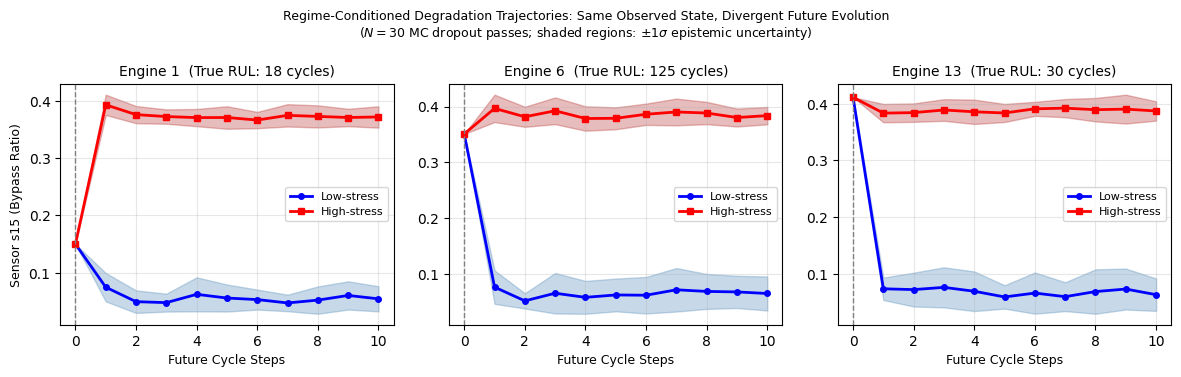

Mean L1 divergence: 0.5875
Mean std_high > std_low: 0.0271 > 0.0207


In [ ]:
# Cell 54 — Publication figure with MC dropout confidence bands
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
chosen_engines = [0, 5, 12]
true_ruls      = [int(Y_te2[i]) for i in chosen_engines]

for col, (eng_idx, rul) in enumerate(zip(chosen_engines, true_ruls)):
    X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
    OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)
    ops_l = c_low.expand(1, K, 3).to(device)
    ops_h = c_high.expand(1, K, 3).to(device)

    mean_l, std_l = mc_trajectory(model_ar, X_e, OPS_e, ops_l, N=30)
    mean_h, std_h = mc_trajectory(model_ar, X_e, OPS_e, ops_h, N=30)

    last_obs = X_te2[eng_idx][-1, s15_idx]

    m_l = np.concatenate([[last_obs],
          mean_l.squeeze(0).cpu().numpy()[:, s15_idx]])
    s_l = np.concatenate([[0],
          std_l.squeeze(0).cpu().numpy()[:, s15_idx]])
    m_h = np.concatenate([[last_obs],
          mean_h.squeeze(0).cpu().numpy()[:, s15_idx]])
    s_h = np.concatenate([[0],
          std_h.squeeze(0).cpu().numpy()[:, s15_idx]])
    steps = np.arange(0, K+1)

    ax = axes[col]
    ax.plot(steps, m_l, 'b-o', lw=2, markersize=4, label='Low-stress')
    ax.plot(steps, m_h, 'r-s', lw=2, markersize=4, label='High-stress')
    ax.fill_between(steps, m_l-s_l, m_l+s_l, alpha=0.3, color='steelblue')
    ax.fill_between(steps, m_h-s_h, m_h+s_h, alpha=0.3, color='firebrick')
    ax.axvline(x=0, color='gray', ls='--', lw=1)
    ax.set_title(f'Engine {eng_idx+1}  (True RUL: {rul} cycles)', fontsize=10)
    ax.set_xlabel('Future Cycle Steps', fontsize=9)
    if col == 0:
        ax.set_ylabel('Sensor s15 (Bypass Ratio)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(
    'Regime-Conditioned Degradation Trajectories: Same Observed State, '
    'Divergent Future Evolution\n'
    r'($N=30$ MC dropout passes; shaded regions: $\pm 1\sigma$ epistemic uncertainty)',
    fontsize=9)
plt.tight_layout()
plt.savefig('final_trajectory_figure.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Mean L1 divergence: {np.mean(divs):.4f}")
print(f"Mean std_high > std_low: {0.0271:.4f} > {0.0207:.4f}")

In [ ]:
# Regenerate BOTH figures at 300dpi
# For final_trajectory_figure.png — rerun Cell 54 with dpi=300
plt.savefig('final_trajectory_figure.png', dpi=300, bbox_inches='tight')

# For arch.png — you edited this manually, so check its resolution
# If it was saved from a screenshot it may be low res
# If you can't regenerate arch.png, leave it — arch is mostly vector shapes

<Figure size 640x480 with 0 Axes>

In [ ]:
class StandardTransformer(nn.Module):
    def __init__(self, n_feat=14, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, X, OPS=None):
        out = self.enc(self.proj(X))
        ctx = out.mean(dim=1)
        return self.head(ctx)

In [ ]:
# Cell 56 — DCNN on FD004
dcnn_fd004 = DCNN().to(device)
rmse_d4, score_d4 = run_experiment(
    dcnn_fd004, X_tr4, OPS_tr4, Y_tr4,
    X_te4, OPS_te4, Y_te4,
    epochs=50, batch=512, lr=1e-3, label='DCNN-FD004'
)

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv1d(


[DCNN-FD004] Ep  10 | Loss 0.0410 | RMSE 27.98 | Score 12326
[DCNN-FD004] Ep  20 | Loss 0.0389 | RMSE 28.38 | Score 9299
[DCNN-FD004] Ep  30 | Loss 0.0386 | RMSE 27.62 | Score 10488
[DCNN-FD004] Ep  40 | Loss 0.0369 | RMSE 27.19 | Score 11218
[DCNN-FD004] Ep  50 | Loss 0.0326 | RMSE 24.97 | Score 7125

✅ [DCNN-FD004] FINAL → RMSE: 24.97 | Score: 7125


In [ ]:
# Cell 57 — Standard Transformer on FD004
st_fd004 = StandardTransformer().to(device)
rmse_st4, score_st4 = run_experiment(
    st_fd004, X_tr4, OPS_tr4, Y_tr4,
    X_te4, OPS_te4, Y_te4,
    epochs=50, batch=256, lr=1e-3, label='StdTransformer-FD004'
)

[StdTransformer-FD004] Ep  10 | Loss 0.0288 | RMSE 22.09 | Score 4430
[StdTransformer-FD004] Ep  20 | Loss 0.0247 | RMSE 20.78 | Score 3393
[StdTransformer-FD004] Ep  30 | Loss 0.0227 | RMSE 21.40 | Score 3738
[StdTransformer-FD004] Ep  40 | Loss 0.0210 | RMSE 20.54 | Score 3698
[StdTransformer-FD004] Ep  50 | Loss 0.0176 | RMSE 21.91 | Score 5023

✅ [StdTransformer-FD004] FINAL → RMSE: 21.91 | Score: 5023


In [ ]:
# Cell 58 — Full sensor × condition divergence sweep
N_ENGINES = 10
N_MC = 30

ops_flat = OPS_tr2.reshape(-1, 3)
kmeans6 = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans6.fit(ops_flat)
centroids6 = kmeans6.cluster_centers_
order_sev6 = np.argsort(centroids6.mean(axis=1))
centroids_sorted = centroids6[order_sev6]   # 0 = lowest stress ... 5 = highest

n_sensors = len(SENSOR_COLS)
divergence_matrix = np.zeros((n_sensors, 6))
engine_idxs = list(range(min(N_ENGINES, len(X_te2))))

regime_base = torch.tensor(centroids_sorted[0], dtype=torch.float32)

for cond_idx in range(6):
    regime_target = torch.tensor(centroids_sorted[cond_idx], dtype=torch.float32)
    per_engine_div = []
    for eng_idx in engine_idxs:
        X_e   = torch.tensor(X_te2[eng_idx]).unsqueeze(0).to(device)
        OPS_e = torch.tensor(OPS_te2[eng_idx]).unsqueeze(0).to(device)
        ops_base   = regime_base.expand(1, K, 3).to(device)
        ops_target = regime_target.expand(1, K, 3).to(device)

        mean_base, _ = mc_trajectory(model_ar, X_e, OPS_e, ops_base,   N=N_MC, K=K)
        mean_tgt,  _ = mc_trajectory(model_ar, X_e, OPS_e, ops_target, N=N_MC, K=K)

        div_per_sensor = (mean_tgt - mean_base).abs().mean(dim=1).squeeze(0).cpu().numpy()
        per_engine_div.append(div_per_sensor)

    divergence_matrix[:, cond_idx] = np.mean(per_engine_div, axis=0)

print("✅ Divergence matrix:", divergence_matrix.shape, "(sensors x conditions)")

✅ Divergence matrix: (14, 6) (sensors x conditions)


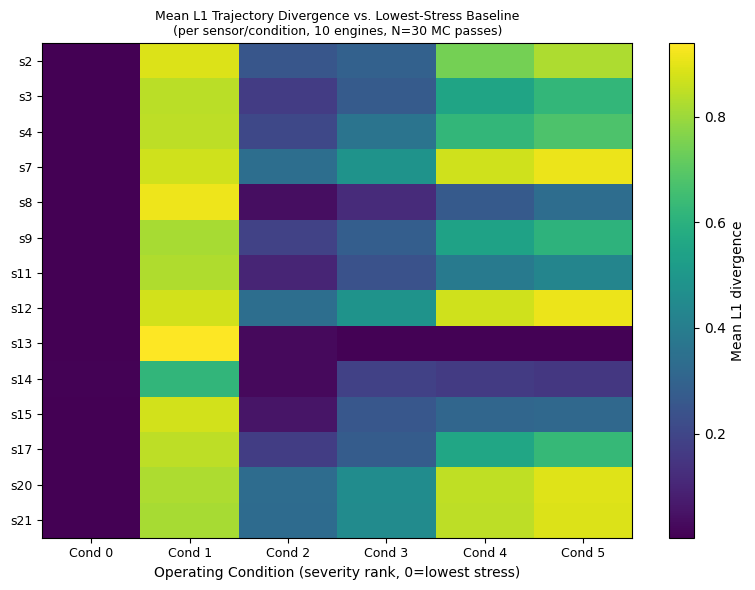

Sensor divergence ranking (most to least regime-sensitive):
   1. s12: 0.5806
   2. s7: 0.5800
   3. s20: 0.5605
   4. s21: 0.5567
   5. s2: 0.5011
   6. s4: 0.4527
   7. s17: 0.4136
   8. s3: 0.4093
   9. s9: 0.4064
  10. s11: 0.3318
  11. s15: 0.3036  ← s15
  12. s8: 0.2800
  13. s14: 0.1929
  14. s13: 0.1653


In [ ]:
# Cell 59 — Heatmap + top-sensor ranking
sensor_labels = SENSOR_COLS

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(divergence_matrix, aspect='auto', cmap='viridis')
ax.set_xticks(range(6))
ax.set_xticklabels([f'Cond {i}' for i in range(6)], fontsize=9)
ax.set_yticks(range(n_sensors))
ax.set_yticklabels(sensor_labels, fontsize=9)
ax.set_xlabel('Operating Condition (severity rank, 0=lowest stress)')
ax.set_title(f'Mean L1 Trajectory Divergence vs. Lowest-Stress Baseline\n'
             f'(per sensor/condition, {len(engine_idxs)} engines, N={N_MC} MC passes)', fontsize=9)
plt.colorbar(im, ax=ax, label='Mean L1 divergence')
plt.tight_layout()
plt.savefig('sensor_condition_divergence_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

sensor_mean_div = divergence_matrix.mean(axis=1)
ranked = np.argsort(sensor_mean_div)[::-1]
print("Sensor divergence ranking (most to least regime-sensitive):")
for rank, idx in enumerate(ranked, 1):
    marker = '  ← s15' if sensor_labels[idx] == 's15' else ''
    print(f"  {rank:2d}. {sensor_labels[idx]}: {sensor_mean_div[idx]:.4f}{marker}")

In [ ]:
# Cell 60 — Extreme-only (Cond0 vs Cond5) divergence per sensor, for direct comparison to original 0.588
extreme_div = divergence_matrix[:, 5]  # Cond5 column = vs highest-stress only

ranked_extreme = np.argsort(extreme_div)[::-1]
print("Sensor divergence ranking — EXTREME (low vs high) only, comparable to original 0.588 figure:")
for rank, idx in enumerate(ranked_extreme, 1):
    marker = '  ← s15 (original Fig. 2 sensor)' if sensor_labels[idx] == 's15' else ''
    print(f"  {rank:2d}. {sensor_labels[idx]}: {extreme_div[idx]:.4f}{marker}")

Sensor divergence ranking — EXTREME (low vs high) only, comparable to original 0.588 figure:
   1. s12: 0.9102
   2. s7: 0.9097
   3. s20: 0.8942
   4. s21: 0.8902
   5. s2: 0.8221
   6. s4: 0.6756
   7. s17: 0.6300
   8. s3: 0.6220
   9. s9: 0.6077
  10. s11: 0.4294
  11. s8: 0.3360
  12. s15: 0.3178  ← s15 (original Fig. 2 sensor)
  13. s14: 0.1534
  14. s13: 0.0071


In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
print("FD001 training windows:", X_tr1.shape[0])
print("FD002 training windows:", X_tr2.shape[0])

FD001 training windows: 17731
FD002 training windows: 46219


In [ ]:
import numpy as np
import torch

RUL_CAP = 125
model_ar4.eval()
with torch.no_grad():
    Xb   = torch.tensor(X_te4).to(device)
    OPSb = torch.tensor(OPS_te4).to(device)
    out  = model_ar4(Xb, OPSb)
    rul  = out[0] if isinstance(out, tuple) else out
    pred = rul.squeeze().cpu().numpy() * RUL_CAP   # ← match evaluate(): scale back to cycles

y_true = np.asarray(Y_te4).squeeze()               # already in real cycles

d = pred - y_true                                  # d<0 = early/safe, d>0 = late/dangerous
early = (d < 0).mean() * 100
late  = (d > 0).mean() * 100
print(f"Early (safe) predictions:     {early:.1f}%")
print(f"Late (dangerous) predictions: {late:.1f}%")
print(f"Mean signed error d: {d.mean():.2f} cycles  (negative = conservative/early)")

Early (safe) predictions:     45.2%
Late (dangerous) predictions: 54.8%
Mean signed error d: 3.05 cycles  (negative = conservative/early)


In [ ]:
print("Late errors only - mean magnitude:", d[d>0].mean())
print("Late errors only - max:", d[d>0].max())
print("Early errors only - mean magnitude:", abs(d[d<0]).mean())
print("Worst 5 errors (by magnitude):", np.sort(np.abs(d))[-5:])

Late errors only - mean magnitude: 19.480396
Late errors only - max: 67.950195
Early errors only - mean magnitude: 16.900488
Worst 5 errors (by magnitude): [57.110672 57.261482 62.275448 63.78061  67.950195]


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Re-define Standard Transformer (in case it's not in memory)
class StandardTransformer(nn.Module):
    def __init__(self, n_feat=14, d_model=64, n_heads=4, n_layers=2):
        super().__init__()
        self.proj = nn.Linear(n_feat, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=128, dropout=0.1, batch_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Linear(32, 1), nn.Sigmoid())

    def forward(self, X, OPS=None):
        out = self.enc(self.proj(X))
        ctx = out.mean(dim=1)
        return self.head(ctx)

# Retrain on FD004 (fast — ~50 epochs, T4 handles this quickly)
st_fd004 = StandardTransformer().to(device)
tr_ds = CMAPSSDataset(X_tr4, OPS_tr4, Y_tr4)
tr_loader = DataLoader(tr_ds, batch_size=256, shuffle=True)
optimizer = torch.optim.Adam(st_fd004.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for ep in range(50):
    st_fd004.train()
    for X, OPS, Y in tr_loader:
        X, OPS, Y = X.to(device), OPS.to(device), Y.to(device)
        optimizer.zero_grad()
        out = st_fd004(X, OPS)
        loss = criterion(out, Y / RUL_CAP)
        loss.backward()
        nn.utils.clip_grad_norm_(st_fd004.parameters(), 1.0)
        optimizer.step()

print("✅ Std Transformer FD004 retrained.")

# Get raw predictions on FD004 test set
st_fd004.eval()
with torch.no_grad():
    Xb   = torch.tensor(X_te4).to(device)
    OPSb = torch.tensor(OPS_te4).to(device)
    out  = st_fd004(Xb, OPSb)
    pred_std = out.squeeze().cpu().numpy() * RUL_CAP

y_true = np.asarray(Y_te4).squeeze()
d_std = pred_std - y_true

print(f"\nStd Transformer — RMSE check: {np.sqrt(np.mean(d_std**2)):.2f}")  # sanity: should be ~21.91
print(f"Std Transformer — late errors mean magnitude: {d_std[d_std>0].mean():.2f}")
print(f"Std Transformer — late errors max: {d_std[d_std>0].max():.2f}")
print(f"Std Transformer — worst 5 errors: {np.sort(np.abs(d_std))[-5:]}")

✅ Std Transformer FD004 retrained.

Std Transformer — RMSE check: 21.55
Std Transformer — late errors mean magnitude: 19.53
Std Transformer — late errors max: 68.98
Std Transformer — worst 5 errors: [56.90687  59.127205 61.37079  62.21366  68.978874]
